# ZINC Guidance Bootstrap

Bootstrap a regression guidance predictor from generated ZINC molecules, inspect random samples from adaptive feasibility buckets each cycle, then compare unguided and guided interpolation samples.

In [1]:
# Enable inline plotting and autoreload, then resolve the repo and NSPPK roots.
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.core.display import HTML
from sklearn.model_selection import train_test_split

HTML('<style>.container { width:95% !important; }</style><style>.output_png {display: table-cell; text-align: center; vertical-align: middle;}</style>')

import sys
from pathlib import Path

for _root in [Path.cwd(), *Path.cwd().parents]:
    if (_root / '_notebook_bootstrap.py').exists():
        _root_str = str(_root.resolve())
        if _root_str not in sys.path:
            sys.path.insert(0, _root_str)
        break
else:
    raise ModuleNotFoundError("Could not locate '_notebook_bootstrap.py' from current notebook directory.")
from _notebook_bootstrap import configure_notebook

globals().update(configure_notebook(require_nsppk=True, print_torch=True))

del _root, _root_str

from conditional_node_field_graph_generator.extensions.demo.pipeline import (
    benchmark_regression_guidance,
    build_graph_generator,
    fit_graph_generator,
)
from conditional_node_field_graph_generator.extensions.molecular import (
    build_zinc_graph_corpus,
    download_zinc_dataset,
    draw_molecules,
    extract_zinc_targets,
    load_zinc_graph_dataset,
)
from conditional_node_field_graph_generator.persistence import (
    list_saved_graph_generators,
    load_graph_generator,
)


PyTorch version: 2.10.0+cpu
CUDA available: False
Enabling RDKit 2025.09.6 jupyter extensions


In [2]:
# Notebook-local helpers for summaries and per-cycle bucket plots.


def show_molecules(graphs, n=None, title=None, legends=None, n_graphs_per_line=4):
    graphs = list(graphs)
    if n is not None:
        graphs = graphs[:n]
    if title:
        print(title)
    if not graphs:
        print('No graphs to display.')
        return
    draw_molecules(
        graphs,
        legends=legends,
        n_graphs_per_line=n_graphs_per_line,
    )


def summarize_graphs(graphs, prefix='dataset'):
    node_counts = np.array([graph.number_of_nodes() for graph in graphs], dtype=int)
    edge_counts = np.array([graph.number_of_edges() for graph in graphs], dtype=int)
    print(f'{prefix}: {len(graphs)} graphs')
    print(f'{prefix}: node count min/median/max = {node_counts.min()}/{int(np.median(node_counts))}/{node_counts.max()}')
    print(f'{prefix}: edge count min/median/max = {edge_counts.min()}/{int(np.median(edge_counts))}/{edge_counts.max()}')


def summarize_generated_batch(batch, label):
    if len(batch) == 0:
        return {
            'label': label,
            'count': 0,
            'feasible_rate': 0.0,
            'mean_violations': 0.0,
            'median_violations': 0.0,
            'mean_target': 0.0,
            'median_target': 0.0,
        }
    return {
        'label': label,
        'count': len(batch),
        'feasible_rate': float(np.mean(batch.feasible_mask)),
        'mean_violations': float(np.mean(batch.violation_counts)),
        'median_violations': float(np.median(batch.violation_counts)),
        'mean_target': float(np.mean(batch.guidance_targets)),
        'median_target': float(np.median(batch.guidance_targets)),
    }


def cycle_summary_frame(history_rows):
    rows = []
    for row in history_rows:
        bucket_counts = ', '.join(
            f"{bucket['label']}:{bucket['count']}"
            for bucket in row['cycle_bucket_summaries']
        )
        rows.append({
            'cycle': row['cycle'],
            'collected_examples': row['collected_examples'],
            'unguided_count': row['unguided_count'],
            'guided_count': row['guided_count'],
            'feasible_rate': row['cycle_feasible_rate'],
            'mean_violations': row['cycle_mean_violation'],
            'median_violations': row['cycle_median_violation'],
            'mean_target': row['cycle_mean_target'],
            'median_target': row['cycle_median_target'],
            'replay_buffer_size': row['replay_buffer_size'],
            'bucket_counts': bucket_counts,
            'train_skipped': not row['train_ran'],
            'skip_reason': row['train_skipped_reason'],
        })
    return pd.DataFrame(rows)


def bucket_plot_payload(graph_generator, batch, per_bucket=4, positive_bucket_count=8, random_state=42):
    rng = np.random.default_rng(random_state)
    payload = []
    for bucket in graph_generator.build_guidance_violation_buckets(
        batch.violation_counts,
        positive_bucket_count=positive_bucket_count,
    ):
        bucket_indices = np.asarray(bucket['indices'], dtype=int)
        if bucket_indices.size == 0:
            continue
        selected = rng.choice(
            bucket_indices,
            size=min(per_bucket, bucket_indices.size),
            replace=False,
        )
        selected = np.asarray(selected, dtype=int)
        payload.append({
            'label': bucket['label'],
            'count': int(bucket_indices.size),
            'median_violation': float(np.median(np.asarray(batch.violation_counts)[bucket_indices])),
            'median_target': float(np.median(np.asarray(batch.guidance_targets)[bucket_indices])),
            'graphs': [batch.decoded_graphs[int(i)] for i in selected],
            'legends': [
                f"v={int(batch.violation_counts[int(i)])}\nt={float(batch.guidance_targets[int(i)]):.3f}"
                for i in selected
            ],
        })
    return payload


def plot_cycle_bucket_samples(graph_generator, batch, cycle_row, per_bucket=4, positive_bucket_count=8, random_state=42):
    payload = bucket_plot_payload(
        graph_generator,
        batch,
        per_bucket=per_bucket,
        positive_bucket_count=positive_bucket_count,
        random_state=random_state,
    )
    if not payload:
        print(f"Cycle {cycle_row['cycle']}: no examples collected.")
        return
    title = (
        f"Cycle {cycle_row['cycle']} | unguided={cycle_row['unguided_count']} guided={cycle_row['guided_count']} | "
        f"collected={cycle_row['collected_examples']} | feasible_rate={cycle_row['cycle_feasible_rate']:.1%} | "
        f"mean_violations={cycle_row['cycle_mean_violation']:.2f} | train_ran={cycle_row['train_ran']}"
    )
    print(title)
    for bucket in payload:
        bucket_title = (
            f"{bucket['label']} | count={bucket['count']} | "
            f"median_violations={bucket['median_violation']:.2f} | median_target={bucket['median_target']:.3f}"
        )
        show_molecules(
            bucket['graphs'],
            title=bucket_title,
            legends=bucket['legends'],
            n_graphs_per_line=min(per_bucket, len(bucket['graphs'])),
        )


ZINC CSV cache: /home/fabrizio/code/NodeField/notebooks/datasets/zinc/zinc_250k.csv
ZINC graph cache root: /home/fabrizio/code/NodeField/notebooks/datasets/zinc
Node-count filter: 9 <= n <= 13
Available node counts: [6, 7, 8, 9, 10, 11, 12, 13, 14, 15] ... [29, 30, 31, 32, 33, 34, 35, 36, 37, 38]
zinc: 3953 graphs
zinc: node count min/median/max = 9/12/13
zinc: edge count min/median/max = 8/13/16


,smiles,logP,qed,SAS
0,Cc1ccc(F)c(Br)n1\n,2.29162,0.572587,2.441051
1,NC(=S)c1n[nH]cc1Br\n,0.80640,0.678925,3.660626
2,CCc1nc(CCl)cs1\n,2.44430,0.607460,2.437301
3,CCOCCOC(=O)Cl\n,1.39830,0.456090,2.373372
4,CO[C@H](C)[C@H](Br)C(=O)[O-]\n,-0.46530,0.595462,4.450078


,logP,qed,SAS
0,2.29162,0.572587,2.441051
1,0.80640,0.678925,3.660626
2,2.44430,0.607460,2.437301
3,1.39830,0.456090,2.373372
4,-0.46530,0.595462,4.450078


train_graphs=3697 test_graphs=64
train_targets.shape=(3697, 3) test_targets.shape=(64, 3)
Training subset preview


[13:05:21] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 10
[13:05:21] Can't kekulize mol.  Unkekulized atoms: 5 6 7 8 11


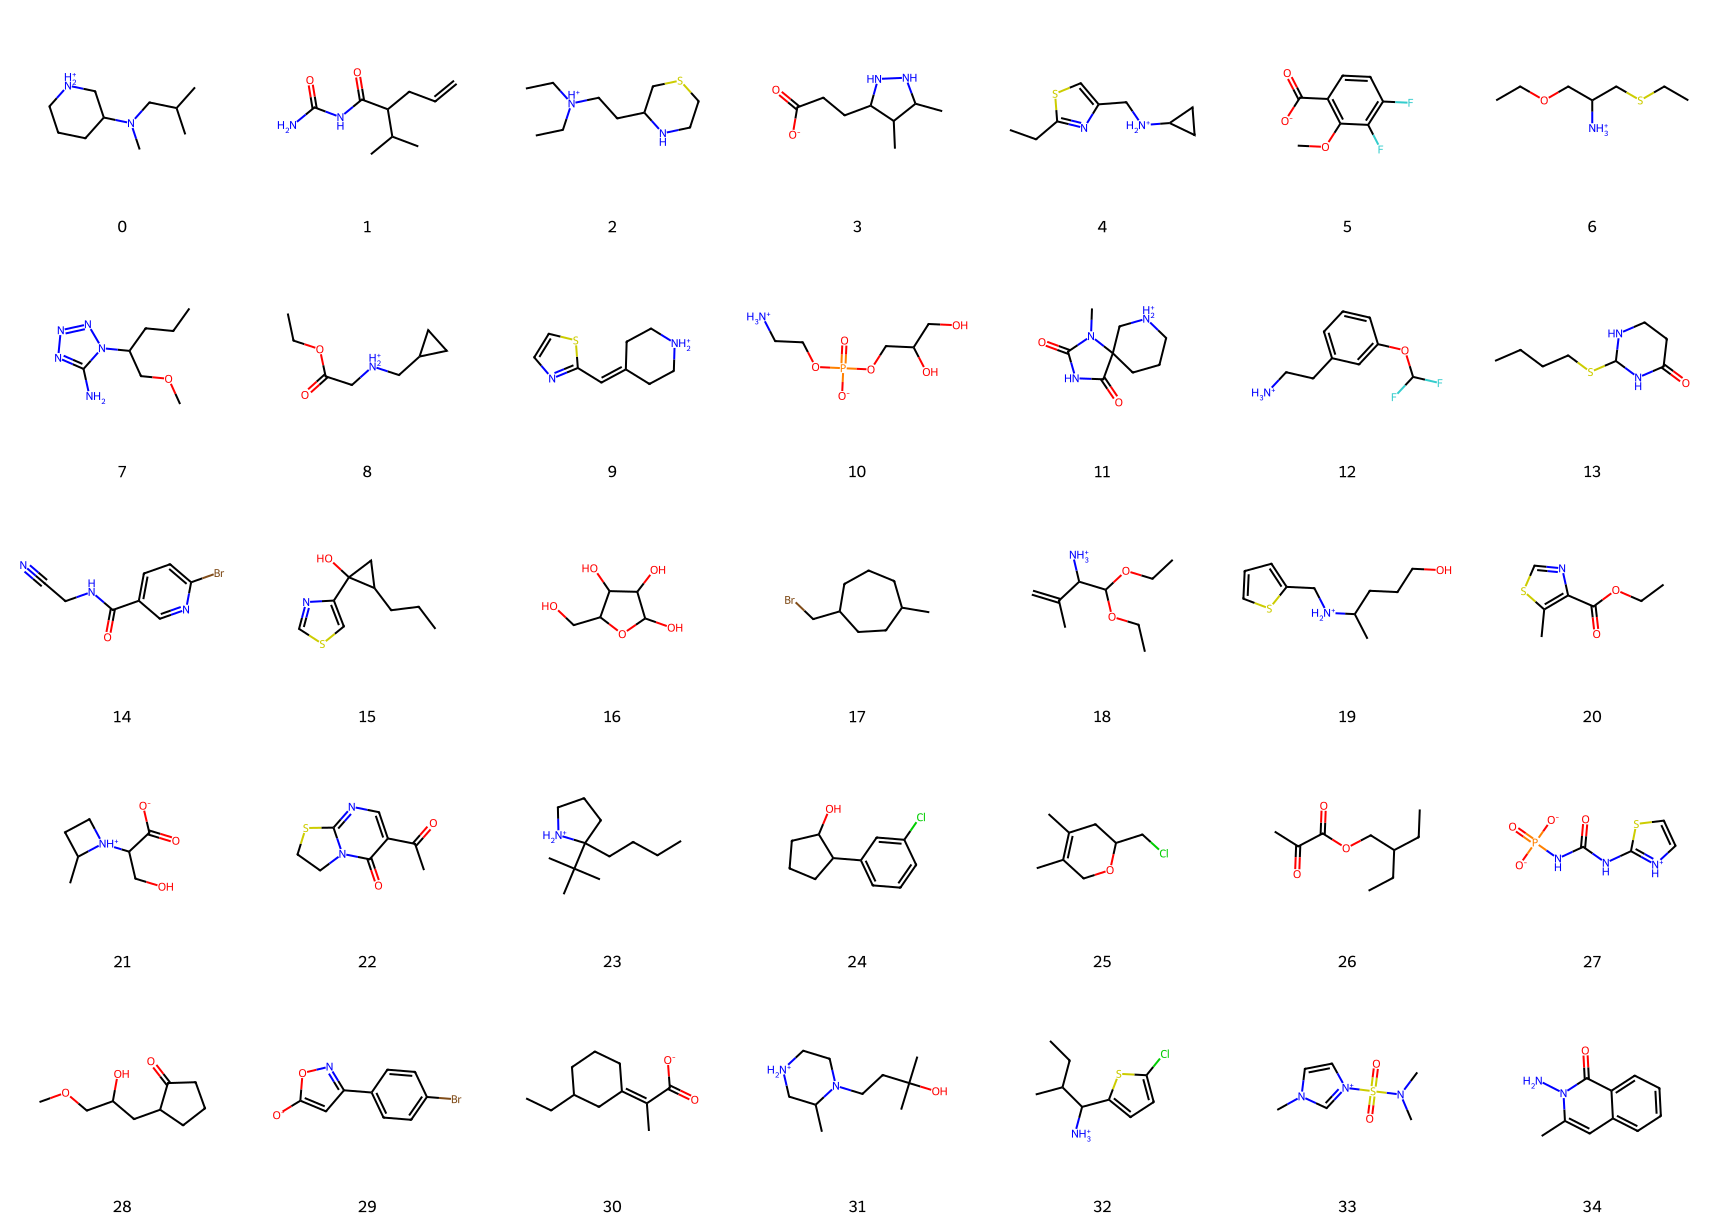

In [3]:
# Build the cached ZINC subset once, then keep a debug-friendly train/test split.

ZINC_DATA_ROOT = NOTEBOOK_DATA_ROOT / 'zinc'
ZINC_MAX_MOLECULES = 250_000
MIN_NODE_COUNT = 9
MAX_NODE_COUNT = 13
TEST_SIZE = 256
RANDOM_STATE = 42
DEBUG_MODE = True
DEBUG_TRAIN_SUBSET = 6000
DEBUG_TEST_SUBSET = 64

csv_path = download_zinc_dataset(ZINC_DATA_ROOT)
corpus_manifest = build_zinc_graph_corpus(ZINC_DATA_ROOT, csv_path=csv_path)
graphs, zinc_metadata = load_zinc_graph_dataset(
    ZINC_DATA_ROOT,
    max_molecules=ZINC_MAX_MOLECULES,
    min_node_count=MIN_NODE_COUNT,
    max_node_count=MAX_NODE_COUNT,
)

print(f'ZINC CSV cache: {csv_path}')
print(f'ZINC graph cache root: {ZINC_DATA_ROOT}')
print(f'Node-count filter: {MIN_NODE_COUNT} <= n <= {MAX_NODE_COUNT}')
print(f"Available node counts: {corpus_manifest['node_counts'][:10]} ... {corpus_manifest['node_counts'][-10:]}")

target_columns = ['logP', 'qed', 'SAS']
targets = torch.tensor(
    extract_zinc_targets(zinc_metadata, target_columns=target_columns).to_numpy(dtype=np.float32),
    dtype=torch.float32,
)

summarize_graphs(graphs, prefix='zinc')
display(zinc_metadata.head())
display(pd.DataFrame(targets.numpy(), columns=target_columns).head())
#show_molecules(graphs, n=7*2, title='Example ZINC molecules', n_graphs_per_line=7)

all_indices = np.arange(len(graphs))
effective_test_size = min(TEST_SIZE, max(1, len(all_indices) // 10))
train_indices, test_indices = train_test_split(
    all_indices,
    test_size=effective_test_size,
    random_state=RANDOM_STATE,
)
train_graphs = [graphs[int(i)] for i in train_indices]
test_graphs = [graphs[int(i)] for i in test_indices]
train_targets = targets[torch.as_tensor(train_indices, dtype=torch.long)]
test_targets = targets[torch.as_tensor(test_indices, dtype=torch.long)]

if DEBUG_MODE:
    rng = np.random.default_rng(RANDOM_STATE)
    train_pick = rng.choice(len(train_graphs), size=min(DEBUG_TRAIN_SUBSET, len(train_graphs)), replace=False)
    test_pick = rng.choice(len(test_graphs), size=min(DEBUG_TEST_SUBSET, len(test_graphs)), replace=False)
    train_graphs = [train_graphs[int(i)] for i in train_pick]
    test_graphs = [test_graphs[int(i)] for i in test_pick]
    train_targets = train_targets[torch.as_tensor(train_pick, dtype=torch.long)]
    test_targets = test_targets[torch.as_tensor(test_pick, dtype=torch.long)]

print(f'train_graphs={len(train_graphs)} test_graphs={len(test_graphs)}')
print(f'train_targets.shape={tuple(train_targets.shape)} test_targets.shape={tuple(test_targets.shape)}')
show_molecules(train_graphs, n=min(7*5, len(train_graphs)), title='Training subset preview', n_graphs_per_line=7)


In [4]:
# Build the ZINC generator. If MODEL_FILENAME is set, the next cell will load it instead of fitting.

NBITS = 11
VERBOSE = 2
MODEL_NAME = f'demo-zinc-bootstrap-n{len(train_graphs)}-size{MIN_NODE_COUNT}-{MAX_NODE_COUNT}'
MODEL_FILENAME = None
FIT_IF_MISSING = True

graph_generator = build_graph_generator(
    nbits=NBITS,
    verbose=VERBOSE,
    feasibility_parallel=False,

    latent_embedding_dimension=128,
    number_of_transformer_layers=3,
    transformer_attention_head_count=4,
    transformer_dropout=0.15,

    learning_rate=2e-4,
    maximum_epochs=200,
    batch_size=16,
    total_steps=100,
    verbose_epoch_interval=10,
    enable_early_stopping=True,
    early_stopping_monitor='val_total',
    early_stopping_mode='min',
    early_stopping_patience=50,
    early_stopping_min_delta=0.1,
    restore_best_checkpoint=True,

    lambda_direct_edge_importance=2.0,
    lambda_auxiliary_edge_importance=1.0,
    lambda_degree_importance=2.0,
    lambda_degree_edge_consistency_importance=0.5,
    lambda_node_exist_importance=2.0,
    lambda_node_count_importance=0.5,
    lambda_node_label_importance=2.0,
    lambda_edge_label_importance=2.0,
    lambda_edge_count_importance=0.5,

    degree_temperature=1.0,
    node_field_sigma=0.2,
    sampling_step_size=0.05,
    langevin_noise_scale=0.0,

    locality_sample_fraction=0.5,
    locality_horizon=1,
    negative_sample_factor=1,
    locality_sampling_strategy='stratified_preserve',
    locality_target_positive_ratio=0.5,
    use_feasibility_filtering=True,
    max_feasibility_attempts=11,
    feasibility_candidates_per_attempt=64,
    feasibility_failure_mode='return_partial',
    feasibility_n_jobs=-1,
    decoder_n_jobs=-1,

    decoder_existence_threshold=0.5,
    decoder_enforce_connectivity=True,
    decoder_degree_slack_penalty=1e6,
    decoder_warm_start_mst=True,

    artifact_root=ARTIFACT_ROOT,
    checkpoint_root=CHECKPOINT_ROOT,
    model_name=MODEL_NAME,
    model_dir=SAVED_GENERATOR_ROOT,
)


Configured graph generator model_name=demo-zinc-bootstrap-n3697-size9-13 model_dir=/home/fabrizio/code/NodeField/.artifacts/saved_generators


No checkpoint selected for resume; training will start from scratch.
Fit target model_name=demo-zinc-bootstrap-n3697-size9-13 model_dir=/home/fabrizio/code/NodeField/.artifacts/saved_generators
Fitting model on 3697 graphs
Fitting feasibility estimator on 3697 graphs
Supervision plan:
  node_labels: mode=learned, enabled. 9 node labels detected.
  edge_labels: mode=learned, enabled. 4 edge labels detected.
  direct_edges: mode=learned, enabled, horizon=1. Generator should learn horizon-1 edge presence for the decoder.
  auxiliary_locality: mode=disabled, disabled. No auxiliary locality is needed when locality_horizon=1.
adj_mtx_to_targets[direct_edge, horizon=1]: sampling 271844 pairs (50.00%) from 543688 total pairs (pos=181844, neg=361844, negative_sample_factor=1, sampling_strategy=stratified_preserve, target_positive_ratio=0.500).
adj_mtx_to_targets[direct_edge, horizon=1]: using pos=90922, neg=180922, positive_ratio=0.334.
Training conditional model on 3697 graphs with up to 13 no

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
/home/fabrizio/.venvs/py313/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Epoch 10/200 | ETA 5h 38m 45s:
  train total=   27.549 | node_field    24.548 [89.1%] |        deg   0.90320 [3.3%] |      exist   0.08476 [0.3%] | node_count   0.00084 [<0.1%]
  val   total=   27.300 | node_field    24.523 [89.8%] |        deg   0.83022 [3.0%] |      exist   0.07624 [0.3%] | node_count   0.00072 [<0.1%]
  train                 | node_label   0.09488 [0.3%] | edge_label   0.28245 [1.0%] |       edge    1.5277 [5.5%] | edge_count   0.10723 [0.4%] | deg_edge_consistency   0.00031 [<0.1%] | dominant=node_field [89.1%]
  val                   | node_label   0.06919 [0.3%] | edge_label   0.22487 [0.8%] |       edge    1.4667 [5.4%] | edge_count   0.10931 [0.4%] | deg_edge_consistency   0.00027 [<0.1%] | dominant=node_field [89.8%]
Epoch 20/200 | ETA 5h 12m 34s:
  train total=   26.943 | node_field    24.496 [90.9%] |        deg   0.70267 [2.6%] |      exist   0.06360 [0.2%] | node_count   0.00056 [<0.1%]
  val   total=   26.871 | node_field    24.486 [91.1%] |        deg   

`Trainer.fit` stopped: `max_epochs=200` reached.


Epoch 200/200 | ETA 0h 00m 00s:
  train total=   25.308 | node_field    24.342 [96.2%] |        deg   0.19856 [0.8%] |      exist   0.00019 [<0.1%] | node_count   0.00000 [<0.1%]
  val   total=   25.580 | node_field    24.355 [95.2%] |        deg   0.31731 [1.2%] |      exist   0.00017 [<0.1%] | node_count   0.00000 [<0.1%]
  train                 | node_label   0.01445 [<0.1%] | edge_label   0.05387 [0.2%] |       edge   0.66576 [2.6%] | edge_count   0.03380 [0.1%] | deg_edge_consistency   0.00007 [<0.1%] | dominant=node_field [96.2%]
  val                   | node_label   0.03289 [0.1%] | edge_label   0.10551 [0.4%] |       edge   0.72808 [2.8%] | edge_count   0.04065 [0.2%] | deg_edge_consistency   0.00010 [<0.1%] | dominant=node_field [95.2%]


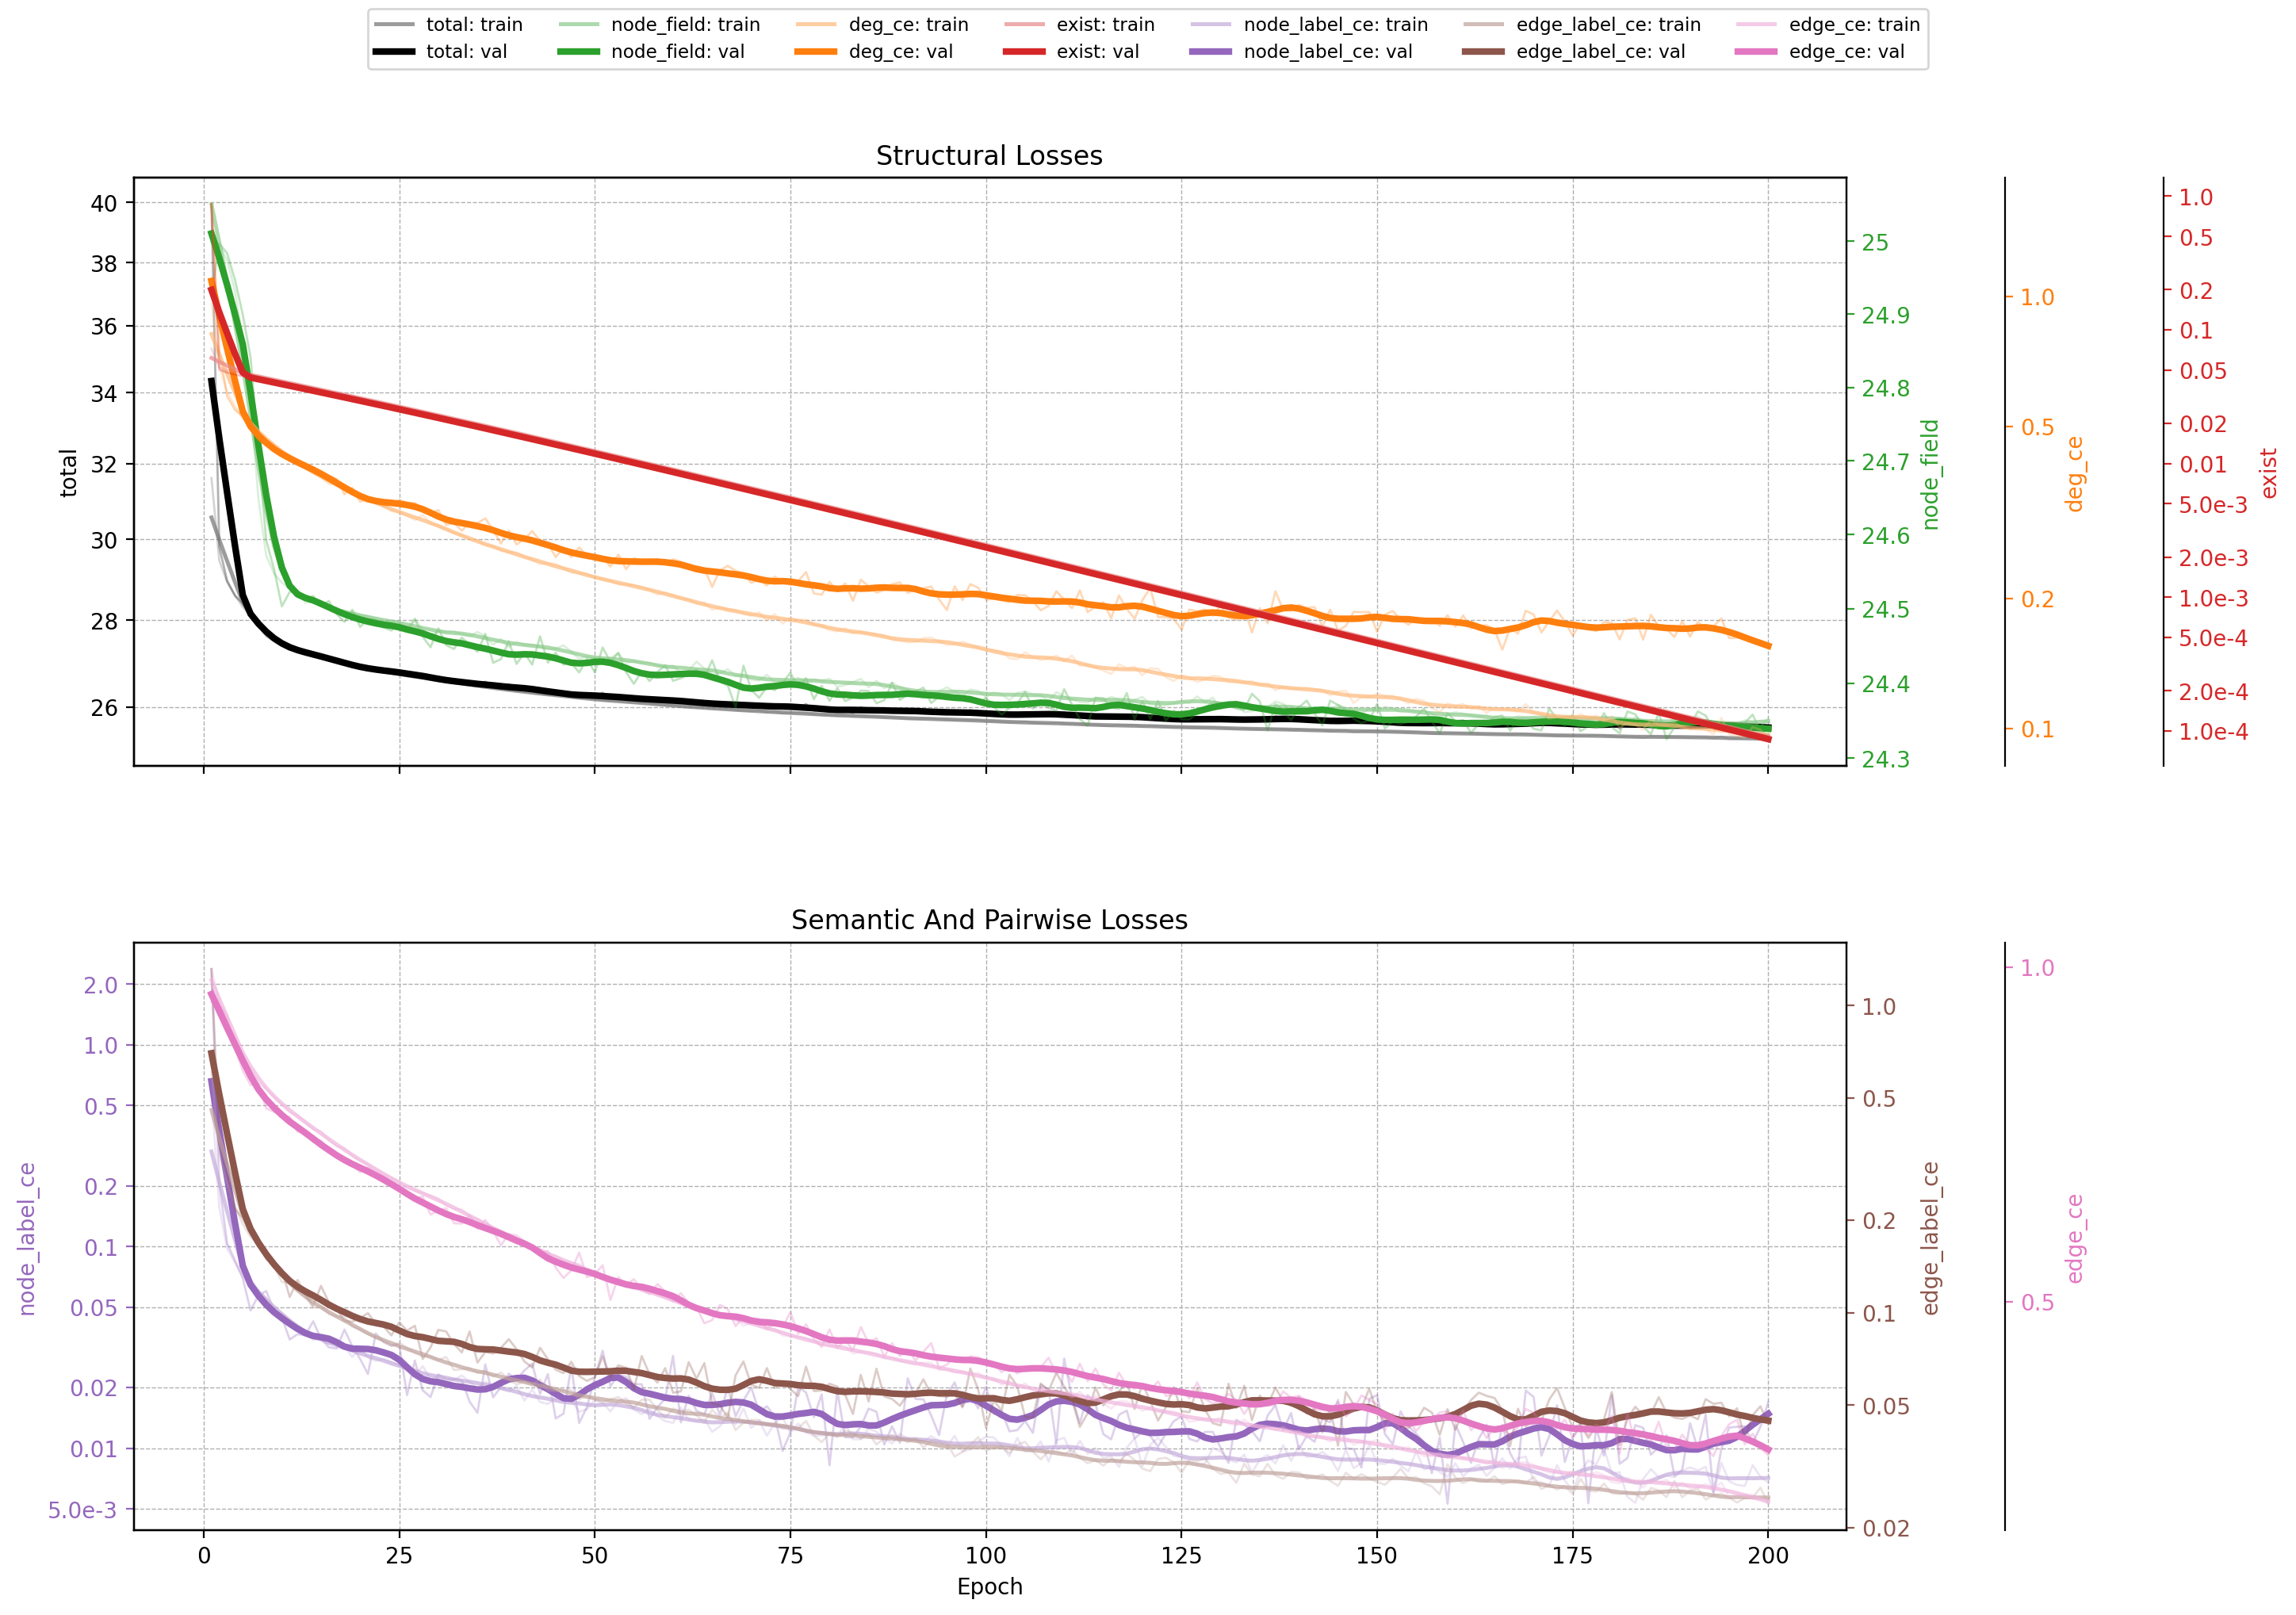

Restored best checkpoint: best_epoch=180, val_total=25.5239, raw_val_node_field=24.3414, stopped_epoch=201
  path=/home/fabrizio/code/NodeField/.artifacts/checkpoints/node_field/ConditionalNodeFieldGenerator_e5ad4b24c9554e738d0d7594ae85b9d0/best-179-25.5239.ckpt
Saved graph generator as: demo-zinc-bootstrap-n3697-size9-13-20260320-0043-47f9ef.pkl
/home/fabrizio/code/NodeField/.artifacts/saved_generators/demo-zinc-bootstrap-n3697-size9-13-20260320-0043-47f9ef.pkl
model_name=demo-zinc-bootstrap-n3697-size9-13
model_dir=/home/fabrizio/code/NodeField/.artifacts/saved_generators
CPU times: user 7d 6h 27min 59s, sys: 2h 11min 45s, total: 7d 8h 39min 45s
Wall time: 5h 40min 28s


In [5]:
%%time
# Load a saved full generator when MODEL_FILENAME is set; otherwise fit from scratch when FIT_IF_MISSING is True.

if MODEL_FILENAME:
    graph_generator = load_graph_generator(MODEL_FILENAME, model_dir=SAVED_GENERATOR_ROOT)
    print(f'Loaded full generator: {MODEL_FILENAME}')
elif FIT_IF_MISSING:
    graph_generator = fit_graph_generator(
        graph_generator,
        train_graphs,
        resume_latest_checkpoint=False,
        checkpoint_root=CHECKPOINT_ROOT,
    )
else:
    raise RuntimeError('Set MODEL_FILENAME or FIT_IF_MISSING=True before running bootstrap.')

print(f'model_name={getattr(graph_generator, "model_name", None)}')
print(f'model_dir={getattr(graph_generator, "model_dir", None)}')


In [5]:
# Inspect the saved full generators before choosing one to reload for bootstrap reruns.

list_saved_graph_generators(SAVED_GENERATOR_ROOT)


,name,modified,size_mb
0,demo-zinc-n1600-size8-12-20260320-1250-bd0649.pkl,2026-03-20 12:50,29.6
1,demo-zinc-bootstrap-n3697-size9-13-20260320-00...,2026-03-20 00:43,66.3
2,demo-zinc-n911-size6-11-20260319-1823-8bebf8.pkl,2026-03-19 18:23,22.7
3,demo-zinc-n911-size6-11-20260319-1621-1f896f.pkl,2026-03-19 16:21,22.7
4,demo-artificial-n486-size8-20260318-1652-cec30...,2026-03-18 16:52,10.7


['demo-zinc-n1600-size8-12-20260320-1250-bd0649.pkl',
 'demo-zinc-bootstrap-n3697-size9-13-20260320-0043-47f9ef.pkl',
 'demo-zinc-n911-size6-11-20260319-1823-8bebf8.pkl',
 'demo-zinc-n911-size6-11-20260319-1621-1f896f.pkl',
 'demo-artificial-n486-size8-20260318-1652-cec308.pkl']

In [6]:
# Optional: reload a previously saved full generator before rerunning the bootstrap loop.
# Set RELOAD_GENERATOR_FILENAME to one of the filenames listed above.

RELOAD_GENERATOR_FILENAME = 'demo-zinc-bootstrap-n3697-size9-13-20260320-0043-47f9ef.pkl'

if RELOAD_GENERATOR_FILENAME:
    graph_generator = load_graph_generator(RELOAD_GENERATOR_FILENAME, model_dir=SAVED_GENERATOR_ROOT)
    print(f'Reloaded full generator: {RELOAD_GENERATOR_FILENAME}')
    print(f'model_name={getattr(graph_generator, "model_name", None)}')
    print(f'model_dir={getattr(graph_generator, "model_dir", None)}')
else:
    print('Set RELOAD_GENERATOR_FILENAME to reload a saved full generator before rerunning bootstrap.')


Loaded graph generator: demo-zinc-bootstrap-n3697-size9-13-20260320-0043-47f9ef.pkl
/home/fabrizio/code/NodeField/.artifacts/saved_generators/demo-zinc-bootstrap-n3697-size9-13-20260320-0043-47f9ef.pkl
Reloaded full generator: demo-zinc-bootstrap-n3697-size9-13-20260320-0043-47f9ef.pkl
model_name=demo-zinc-bootstrap-n3697-size9-13
model_dir=/home/fabrizio/code/NodeField/.artifacts/saved_generators


In [ ]:
# Bootstrap configuration.

BOOTSTRAP_CYCLES = 12
EXAMPLES_PER_CYCLE = 128
INTERPOLATE_BETWEEN_N_SAMPLES = 10
REPLAY_TRAIN_SIZE = 512
POSITIVE_VIOLATION_BUCKETS = 8
GUIDED_FRACTION_AFTER_FIRST_CYCLE = 0.75
GUIDED_TARGET = 1.0
GUIDANCE_LEARNING_RATE = 1e-3
GUIDANCE_MAXIMUM_EPOCHS = 40
GUIDANCE_BATCH_SIZE = 64
GUIDANCE_NOISE_SCALE = 0.0
GUIDANCE_PREDICTOR_SCALE = 1.0
PLOT_MOLECULES_PER_BUCKET = 4
PLOT_RANDOM_STATE = 42

print('Guidance target formula: 1 / (1 + sqrt(number_of_violations))')


Guidance target formula: 1 / (1 + sqrt(number_of_violations))


In [8]:
%%time
# Run the generated-sample bootstrap loop.

bootstrap_results = graph_generator.bootstrap_guidance_regressor_from_generated(
    num_cycles=BOOTSTRAP_CYCLES,
    examples_per_cycle=EXAMPLES_PER_CYCLE,
    interpolate_between_n_samples=INTERPOLATE_BETWEEN_N_SAMPLES,
    replay_train_size=REPLAY_TRAIN_SIZE,
    positive_bucket_count=POSITIVE_VIOLATION_BUCKETS,
    guided_fraction_after_first_cycle=GUIDED_FRACTION_AFTER_FIRST_CYCLE,
    guided_target=GUIDED_TARGET,
    guidance_learning_rate=GUIDANCE_LEARNING_RATE,
    guidance_maximum_epochs=GUIDANCE_MAXIMUM_EPOCHS,
    guidance_batch_size=GUIDANCE_BATCH_SIZE,
    guidance_noise_scale=GUIDANCE_NOISE_SCALE,
    predictor_scale=GUIDANCE_PREDICTOR_SCALE,
    random_state=PLOT_RANDOM_STATE,
)

cycle_history = bootstrap_results['history']
cycle_batches = bootstrap_results['cycle_batches']
replay_buffer = bootstrap_results['replay_buffer']
print(f'cycles={len(cycle_history)} replay_buffer={len(replay_buffer)}')


cycles=8 replay_buffer=1024
CPU times: user 8h 29min 29s, sys: 10min 21s, total: 8h 39min 51s
Wall time: 37min 45s


In [9]:
# Compact cycle summary table.

summary_df = cycle_summary_frame(cycle_history)
display(summary_df)


,cycle,collected_examples,unguided_count,guided_count,feasible_rate,mean_violations,median_violations,mean_target,median_target,replay_buffer_size,bucket_counts,train_skipped,skip_reason
0,1,128,128,0,0.093750,12.406250,10.5,0.307815,0.235958,128,"feasible:12, q1: [3, 5]:14, q2: [5, 7]:10, q3:...",False,None
1,2,128,32,96,0.085938,14.835938,11.0,0.291591,0.231662,256,"feasible:11, q1: [2, 6]:13, q2: [6, 7]:5, q3: ...",False,None
2,3,128,32,96,0.093750,12.992188,10.5,0.307102,0.235958,384,"feasible:12, q1: [3, 5]:12, q2: [5, 7]:13, q3:...",False,None
3,4,128,32,96,0.070312,15.039062,12.0,0.280315,0.224009,512,"feasible:9, q1: [3, 5]:8, q2: [5, 7]:17, q3: [...",False,None
4,5,128,32,96,0.140625,15.851562,12.0,0.326205,0.224009,640,"feasible:18, q1: [3, 6]:12, q2: [6, 9]:15, q3:...",False,None
5,6,128,32,96,0.070312,15.468750,12.5,0.279405,0.220569,768,"feasible:9, q1: [3, 6]:15, q2: [6, 7]:8, q3: [...",False,None
6,7,128,32,96,0.046875,15.867188,11.0,0.261782,0.231662,896,"feasible:6, q1: [3, 6]:12, q2: [6, 7]:8, q3: [...",False,None
7,8,128,32,96,0.070312,14.640625,11.5,0.282091,0.227836,1024,"feasible:9, q1: [3, 6]:13, q2: [6, 7]:8, q3: [...",False,None


Cycle 1 | unguided=128 guided=0 | collected=128 | feasible_rate=9.4% | mean_violations=12.41 | train_ran=True
feasible | count=12 | median_violations=0.00 | median_target=1.000


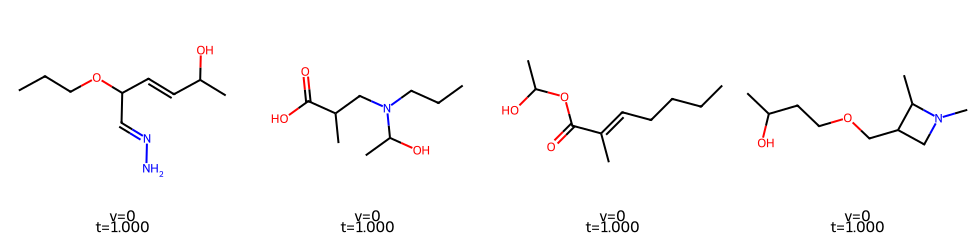

q1: [3, 5] | count=14 | median_violations=4.00 | median_target=0.333


[13:43:10] non-ring atom 10 marked aromatic


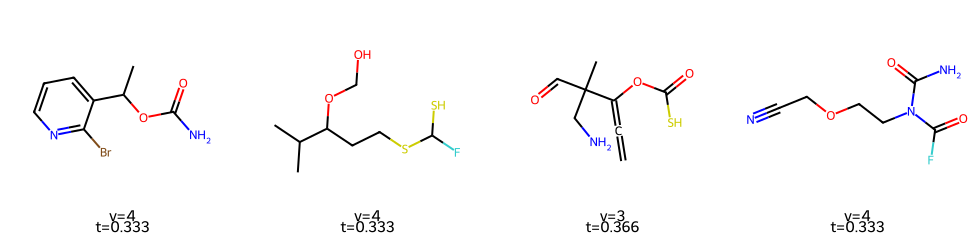

q2: [5, 7] | count=10 | median_violations=6.00 | median_target=0.290


[13:43:10] non-ring atom 2 marked aromatic
[13:43:10] Explicit valence for atom # 8 C, 5, is greater than permitted
[13:43:10] non-ring atom 3 marked aromatic
[13:43:10] non-ring atom 1 marked aromatic


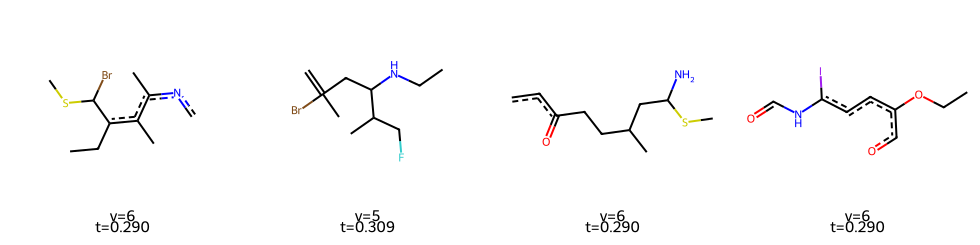

q3: [7, 8] | count=10 | median_violations=7.00 | median_target=0.274


[13:43:10] non-ring atom 3 marked aromatic
[13:43:10] non-ring atom 3 marked aromatic
[13:43:10] Can't kekulize mol.  Unkekulized atoms: 8
[13:43:10] non-ring atom 1 marked aromatic


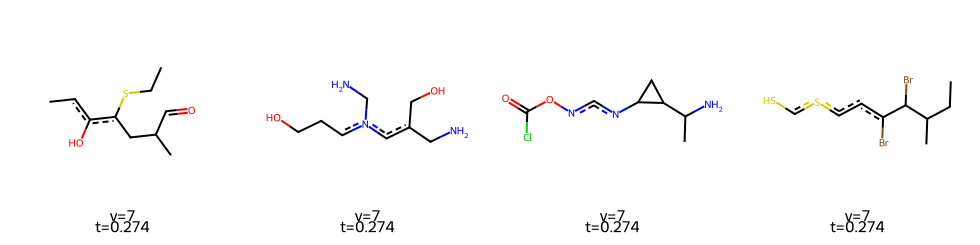

q4: [8, 12] | count=22 | median_violations=8.00 | median_target=0.261


[13:43:10] non-ring atom 0 marked aromatic
[13:43:10] Explicit valence for atom # 2 O, 3, is greater than permitted
[13:43:10] non-ring atom 1 marked aromatic


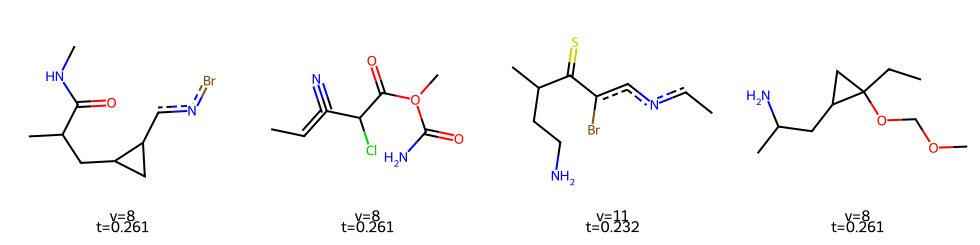

q5: [12, 14] | count=15 | median_violations=13.00 | median_target=0.217


[13:43:10] non-ring atom 0 marked aromatic
[13:43:10] Can't kekulize mol.  Unkekulized atoms: 5 7 12
[13:43:10] Explicit valence for atom # 3 N, 4, is greater than permitted


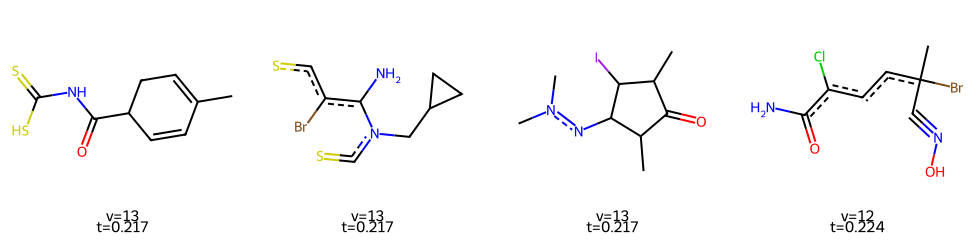

q6: [14, 16] | count=12 | median_violations=14.00 | median_target=0.211


[13:43:10] Can't kekulize mol.  Unkekulized atoms: 3 7 9
[13:43:10] non-ring atom 8 marked aromatic
[13:43:10] Can't kekulize mol.  Unkekulized atoms: 1 4 6


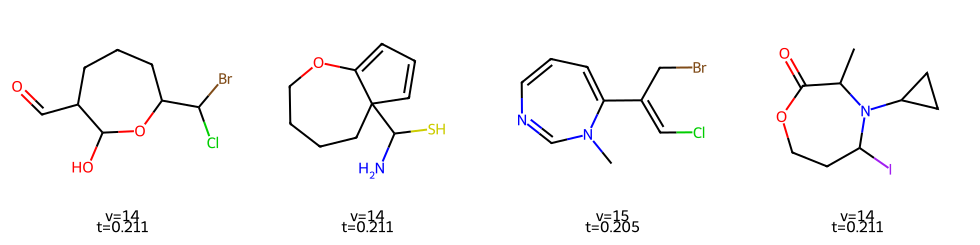

q7: [16, 25] | count=18 | median_violations=17.50 | median_target=0.193


[13:43:10] Explicit valence for atom # 6 C, 5, is greater than permitted
[13:43:10] Can't kekulize mol.  Unkekulized atoms: 7 10 11
[13:43:10] Explicit valence for atom # 7 O, 3, is greater than permitted


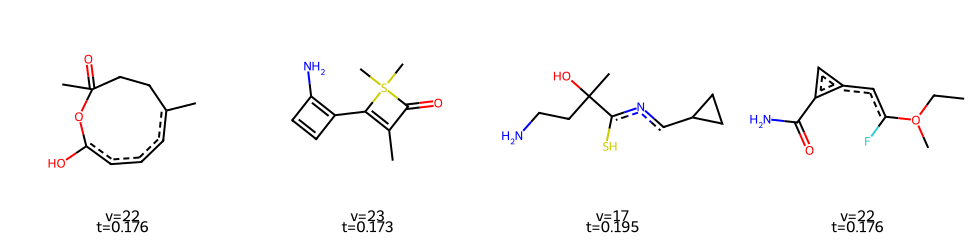

q8: [25, 52] | count=15 | median_violations=33.00 | median_target=0.148


[13:43:10] Explicit valence for atom # 7 C, 5, is greater than permitted
[13:43:10] Can't kekulize mol.  Unkekulized atoms: 0 3 11
[13:43:10] Can't kekulize mol.  Unkekulized atoms: 3 4 8
[13:43:10] Can't kekulize mol.  Unkekulized atoms: 0 3 5


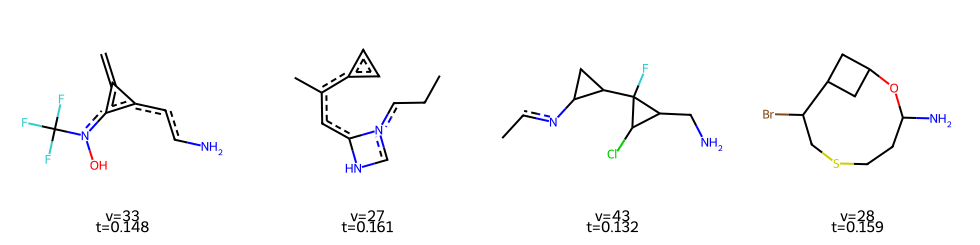

Cycle 2 | unguided=32 guided=96 | collected=128 | feasible_rate=8.6% | mean_violations=14.84 | train_ran=True
feasible | count=11 | median_violations=0.00 | median_target=1.000


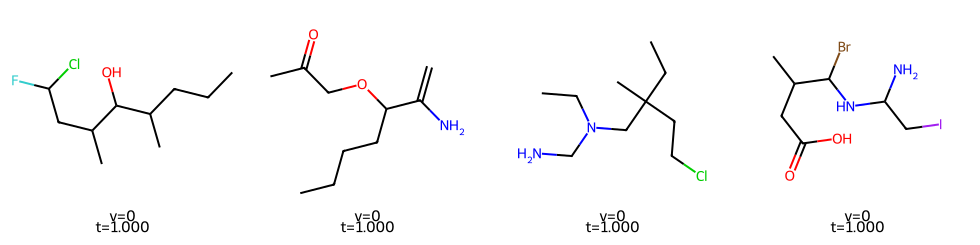

q1: [2, 6] | count=13 | median_violations=4.00 | median_target=0.333


[13:43:10] Explicit valence for atom # 10 C, 6, is greater than permitted
[13:43:10] Explicit valence for atom # 8 C, 5, is greater than permitted


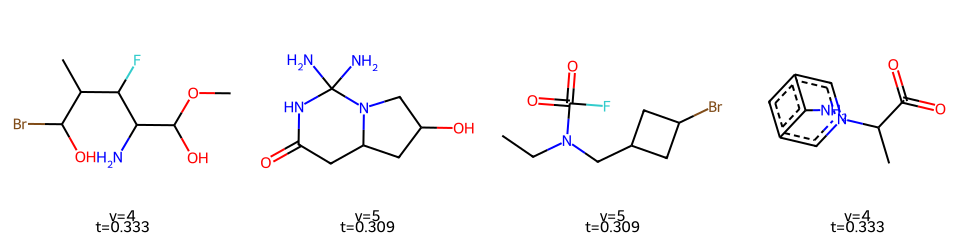

q2: [6, 7] | count=5 | median_violations=6.00 | median_target=0.290


[13:43:10] Can't kekulize mol.  Unkekulized atoms: 4
[13:43:10] non-ring atom 1 marked aromatic
[13:43:10] non-ring atom 1 marked aromatic
[13:43:10] non-ring atom 1 marked aromatic


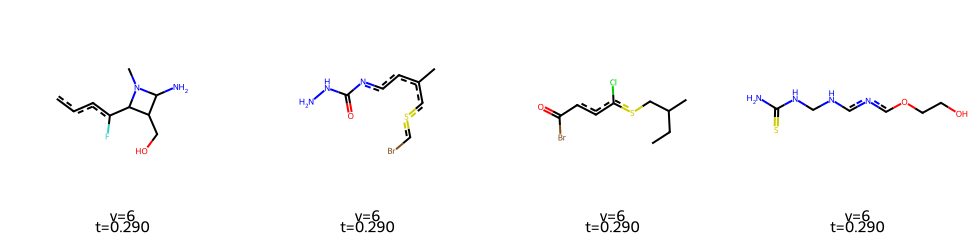

q3: [7, 10] | count=26 | median_violations=7.50 | median_target=0.268


[13:43:10] non-ring atom 4 marked aromatic
[13:43:10] non-ring atom 6 marked aromatic
[13:43:10] Can't kekulize mol.  Unkekulized atoms: 1
[13:43:10] Can't kekulize mol.  Unkekulized atoms: 1 4 11


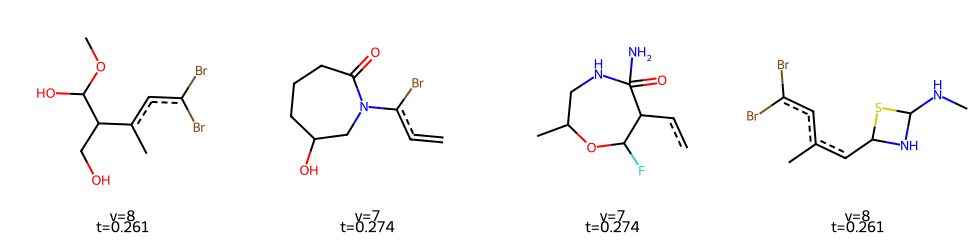

q4: [10, 13] | count=14 | median_violations=11.00 | median_target=0.232


[13:43:10] Explicit valence for atom # 5 C, 5, is greater than permitted
[13:43:10] Explicit valence for atom # 11 O, 3, is greater than permitted
[13:43:10] non-ring atom 0 marked aromatic
[13:43:10] Explicit valence for atom # 8 N, 4, is greater than permitted


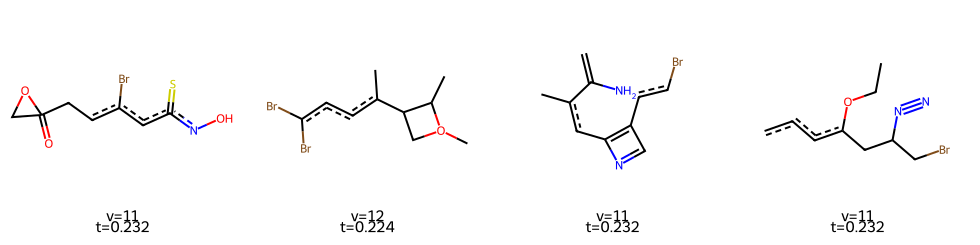

q5: [13, 16] | count=11 | median_violations=13.00 | median_target=0.217


[13:43:10] Explicit valence for atom # 6 O, 3, is greater than permitted
[13:43:10] Can't kekulize mol.  Unkekulized atoms: 2 11 12
[13:43:10] non-ring atom 1 marked aromatic


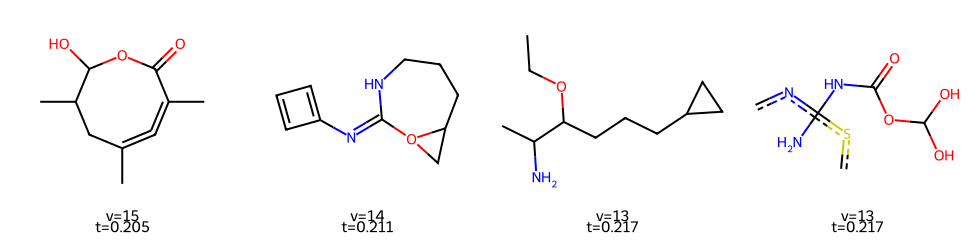

q6: [16, 22] | count=16 | median_violations=18.00 | median_target=0.191


[13:43:10] Can't kekulize mol.  Unkekulized atoms: 0 2 3 8 11
[13:43:10] Explicit valence for atom # 6 N, 4, is greater than permitted
[13:43:10] non-ring atom 2 marked aromatic


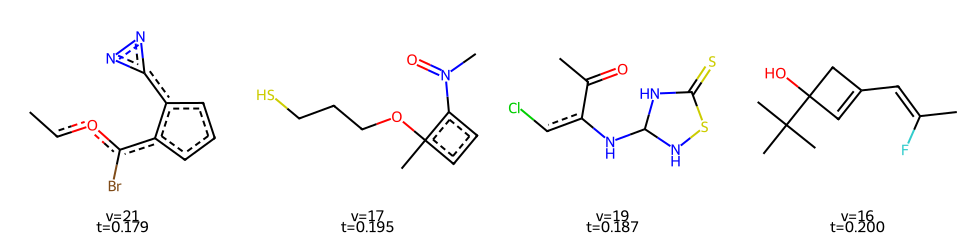

q7: [22, 30] | count=17 | median_violations=25.00 | median_target=0.167


[13:43:10] Explicit valence for atom # 12 O, 4, is greater than permitted
[13:43:10] Explicit valence for atom # 4 C, 5, is greater than permitted
[13:43:10] Can't kekulize mol.  Unkekulized atoms: 7
[13:43:10] Explicit valence for atom # 6 C, 5, is greater than permitted


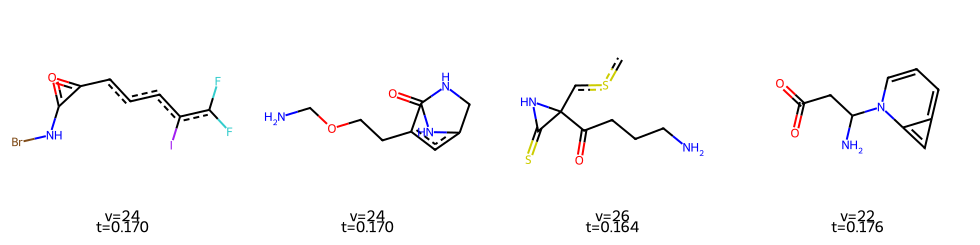

q8: [30, 65] | count=15 | median_violations=38.00 | median_target=0.140


[13:43:10] Explicit valence for atom # 8 N, 6, is greater than permitted
[13:43:10] Can't kekulize mol.  Unkekulized atoms: 0 1 12
[13:43:10] Explicit valence for atom # 10 C, 7, is greater than permitted
[13:43:10] Can't kekulize mol.  Unkekulized atoms: 1 8 9


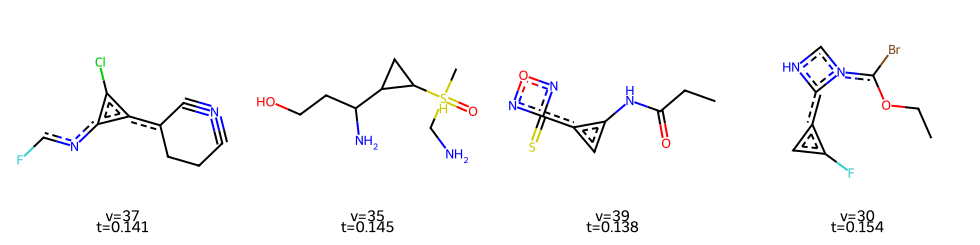

Cycle 3 | unguided=32 guided=96 | collected=128 | feasible_rate=9.4% | mean_violations=12.99 | train_ran=True
feasible | count=12 | median_violations=0.00 | median_target=1.000


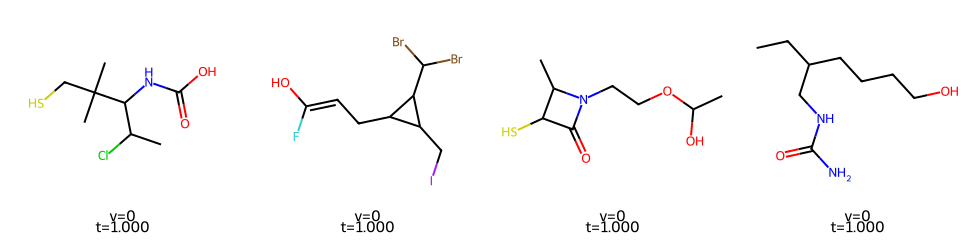

q1: [3, 5] | count=12 | median_violations=4.00 | median_target=0.333


[13:43:10] Explicit valence for atom # 6 C, 5, is greater than permitted
[13:43:10] Explicit valence for atom # 12 O, 3, is greater than permitted
[13:43:10] non-ring atom 9 marked aromatic


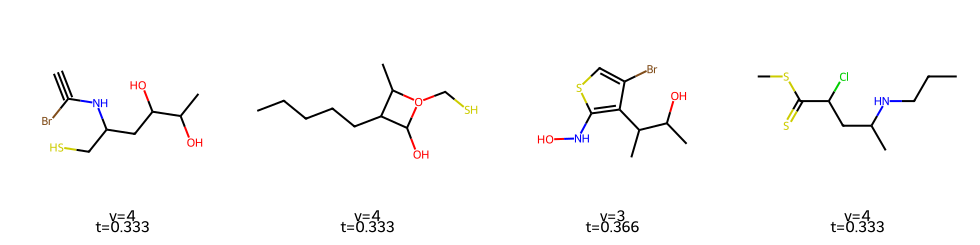

q2: [5, 7] | count=13 | median_violations=6.00 | median_target=0.290


[13:43:10] non-ring atom 0 marked aromatic
[13:43:10] non-ring atom 3 marked aromatic


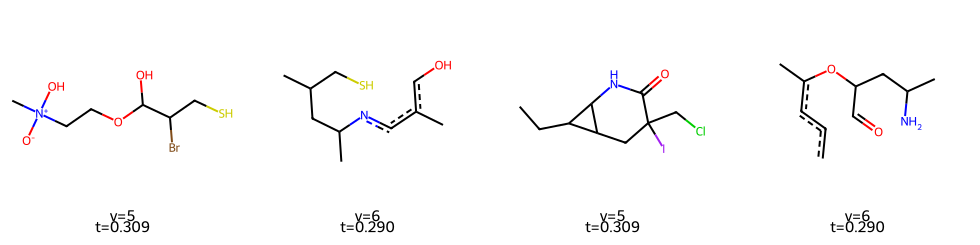

q3: [7, 8] | count=19 | median_violations=7.00 | median_target=0.274


[13:43:10] Explicit valence for atom # 2 C, 5, is greater than permitted
[13:43:10] non-ring atom 4 marked aromatic


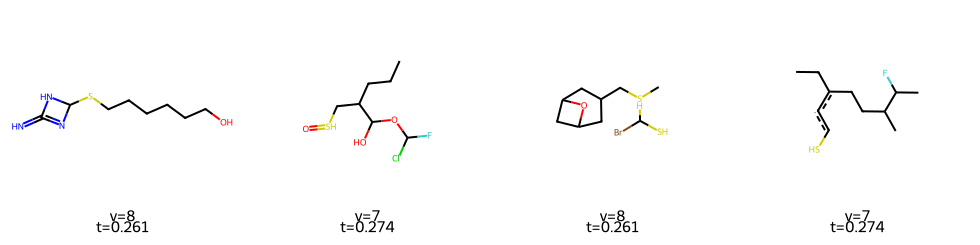

q4: [8, 11] | count=8 | median_violations=10.00 | median_target=0.240


[13:43:10] non-ring atom 3 marked aromatic
[13:43:10] Explicit valence for atom # 1 O, 3, is greater than permitted
[13:43:10] Explicit valence for atom # 10 C, 5, is greater than permitted


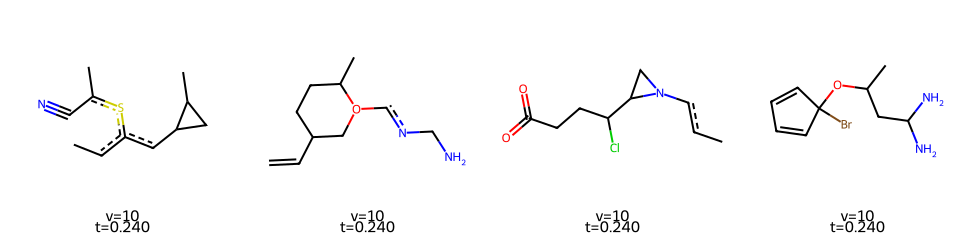

q5: [11, 14] | count=18 | median_violations=11.00 | median_target=0.232


[13:43:11] Can't kekulize mol.  Unkekulized atoms: 1 5 7 9 11
[13:43:11] non-ring atom 1 marked aromatic
[13:43:11] Explicit valence for atom # 3 N, 4, is greater than permitted
[13:43:11] Explicit valence for atom # 6 O, 3, is greater than permitted


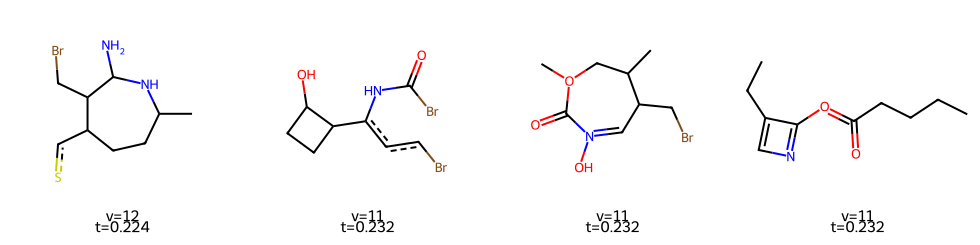

q6: [14, 17] | count=15 | median_violations=15.00 | median_target=0.205


[13:43:11] non-ring atom 0 marked aromatic
[13:43:11] Can't kekulize mol.  Unkekulized atoms: 0 5 7
[13:43:11] Can't kekulize mol.  Unkekulized atoms: 0 5 7 11 12


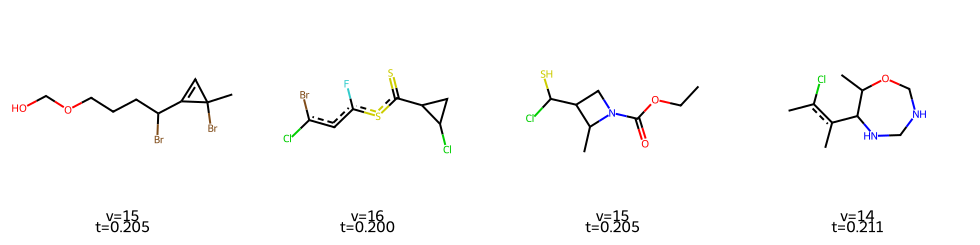

q7: [17, 22] | count=14 | median_violations=18.50 | median_target=0.189


[13:43:11] Explicit valence for atom # 2 C, 5, is greater than permitted
[13:43:11] Can't kekulize mol.  Unkekulized atoms: 0 3 7
[13:43:11] non-ring atom 3 marked aromatic
[13:43:11] Explicit valence for atom # 12 O, 4, is greater than permitted


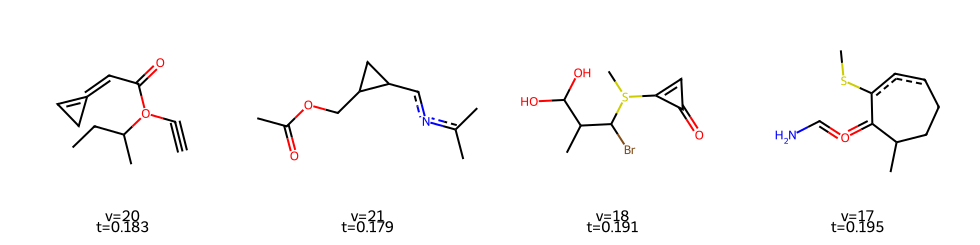

q8: [22, 85] | count=17 | median_violations=29.00 | median_target=0.157


[13:43:11] Can't kekulize mol.  Unkekulized atoms: 6 8 11 12
[13:43:11] Explicit valence for atom # 1 Cl, 2, is greater than permitted
[13:43:11] Explicit valence for atom # 6 C, 6, is greater than permitted


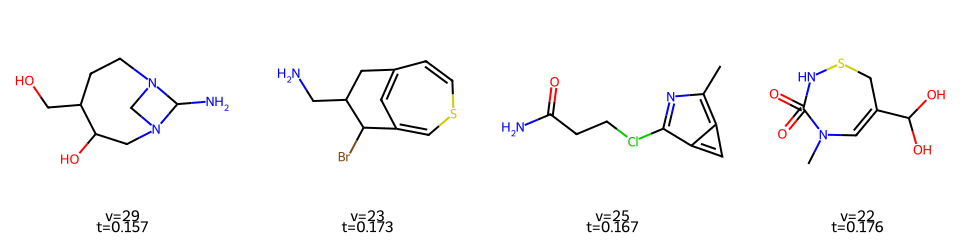

Cycle 4 | unguided=32 guided=96 | collected=128 | feasible_rate=7.0% | mean_violations=15.04 | train_ran=True
feasible | count=9 | median_violations=0.00 | median_target=1.000


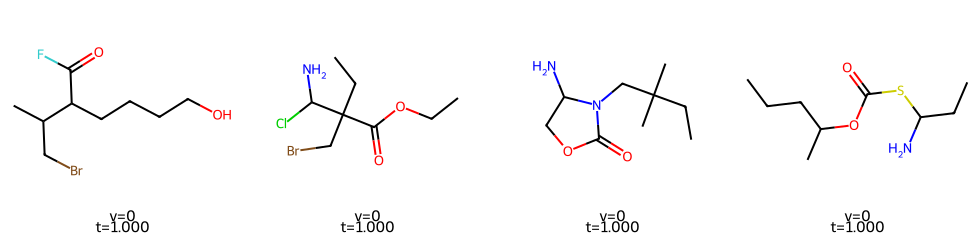

q1: [3, 5] | count=8 | median_violations=4.00 | median_target=0.333


[13:43:11] Can't kekulize mol.  Unkekulized atoms: 0 8 9 10 12
[13:43:11] Explicit valence for atom # 7 C, 5, is greater than permitted


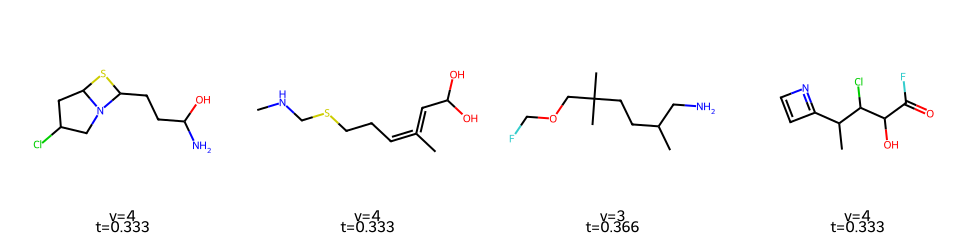

q2: [5, 7] | count=17 | median_violations=6.00 | median_target=0.290


[13:43:11] Explicit valence for atom # 4 C, 5, is greater than permitted
[13:43:11] non-ring atom 0 marked aromatic
[13:43:11] non-ring atom 5 marked aromatic
[13:43:11] non-ring atom 7 marked aromatic


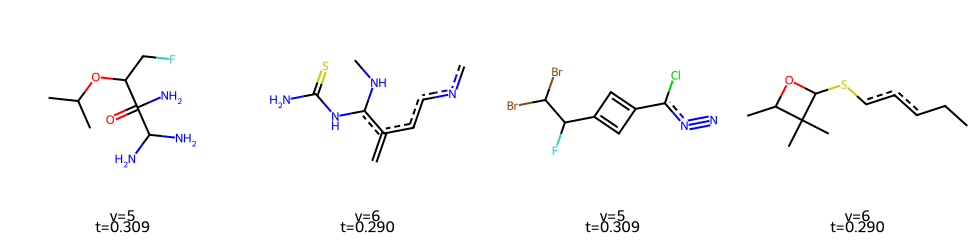

q3: [7, 10] | count=20 | median_violations=8.00 | median_target=0.261


[13:43:11] Can't kekulize mol.  Unkekulized atoms: 12
[13:43:11] non-ring atom 1 marked aromatic
[13:43:11] Can't kekulize mol.  Unkekulized atoms: 0 3 7
[13:43:11] non-ring atom 3 marked aromatic


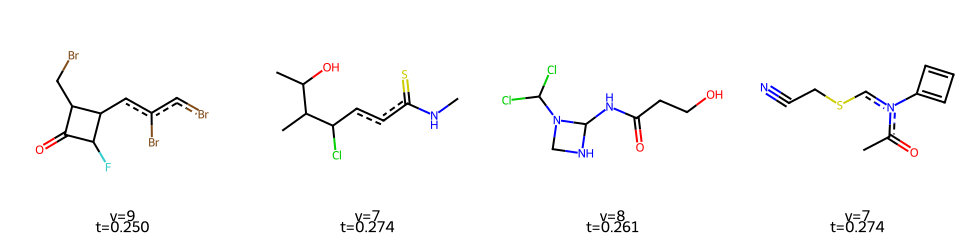

q4: [10, 13] | count=14 | median_violations=12.00 | median_target=0.224


[13:43:11] Explicit valence for atom # 3 C, 5, is greater than permitted
[13:43:11] Explicit valence for atom # 5 C, 5, is greater than permitted
[13:43:11] Can't kekulize mol.  Unkekulized atoms: 3
[13:43:11] non-ring atom 4 marked aromatic


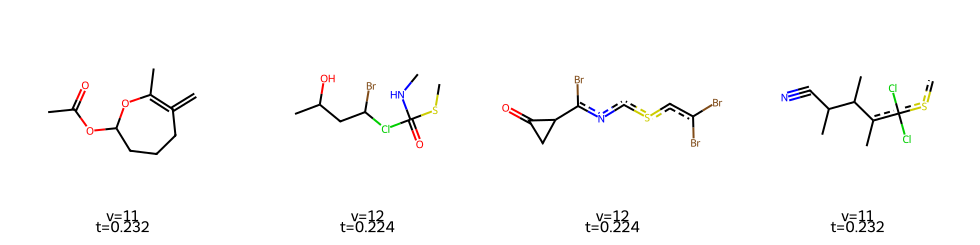

q5: [13, 16] | count=15 | median_violations=14.00 | median_target=0.211


[13:43:11] Can't kekulize mol.  Unkekulized atoms: 1 6 8 9 10 11
[13:43:11] Explicit valence for atom # 7 N, 4, is greater than permitted
[13:43:11] Explicit valence for atom # 4 O, 3, is greater than permitted


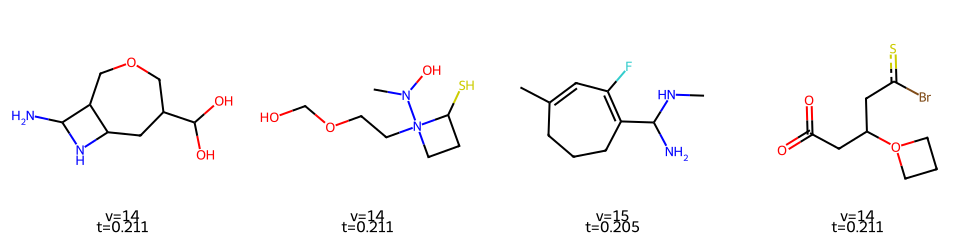

q6: [16, 21] | count=14 | median_violations=18.00 | median_target=0.191


[13:43:11] Explicit valence for atom # 4 C, 5, is greater than permitted
[13:43:11] Can't kekulize mol.  Unkekulized atoms: 12
[13:43:11] Can't kekulize mol.  Unkekulized atoms: 4 5 9
[13:43:11] Can't kekulize mol.  Unkekulized atoms: 7 9 12


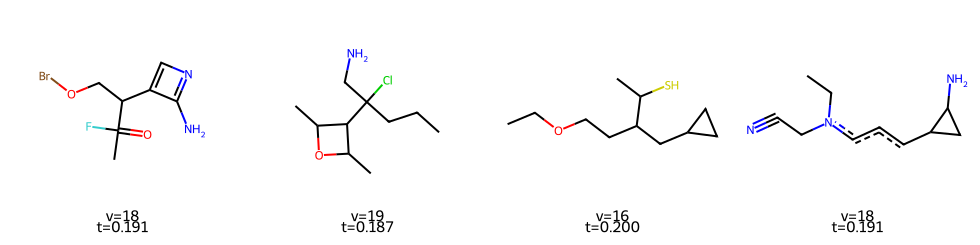

q7: [21, 28] | count=15 | median_violations=23.00 | median_target=0.173


[13:43:11] Can't kekulize mol.  Unkekulized atoms: 2 8 10
[13:43:11] Explicit valence for atom # 10 C, 7, is greater than permitted
[13:43:11] Can't kekulize mol.  Unkekulized atoms: 3 7


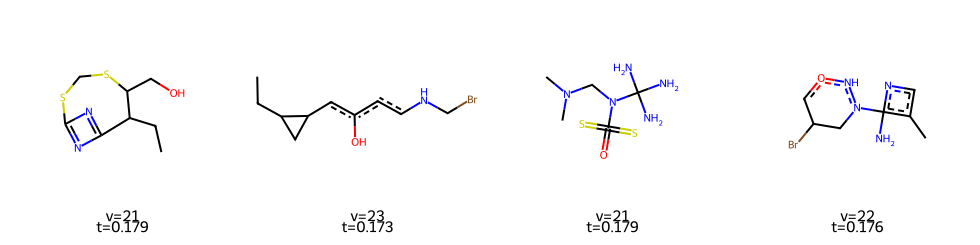

q8: [28, 85] | count=16 | median_violations=36.50 | median_target=0.142


[13:43:11] non-ring atom 1 marked aromatic
[13:43:11] Can't kekulize mol.  Unkekulized atoms: 7
[13:43:11] non-ring atom 0 marked aromatic
[13:43:11] Can't kekulize mol.  Unkekulized atoms: 9 10 11


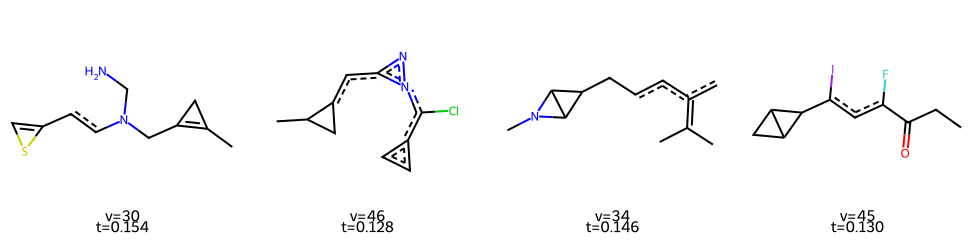

Cycle 5 | unguided=32 guided=96 | collected=128 | feasible_rate=14.1% | mean_violations=15.85 | train_ran=True
feasible | count=18 | median_violations=0.00 | median_target=1.000


[13:43:11] Can't kekulize mol.  Unkekulized atoms: 0 3 4 5 9


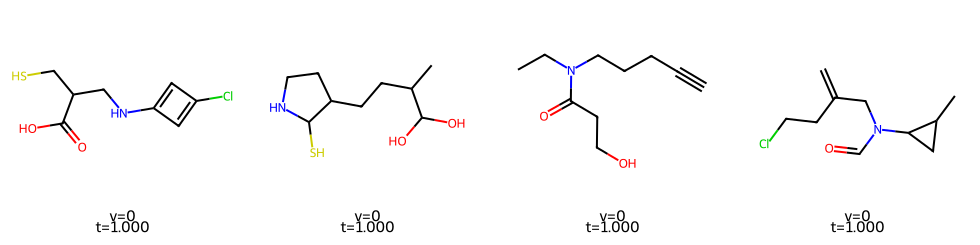

q1: [3, 6] | count=12 | median_violations=4.00 | median_target=0.333


[13:43:11] Explicit valence for atom # 8 O, 3, is greater than permitted


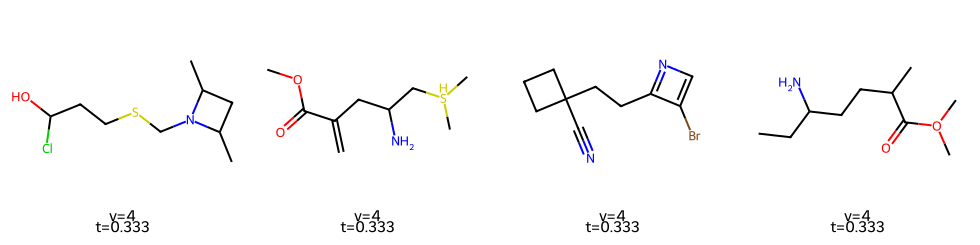

q2: [6, 9] | count=15 | median_violations=7.00 | median_target=0.274


[13:43:11] non-ring atom 2 marked aromatic
[13:43:11] non-ring atom 0 marked aromatic
[13:43:11] Explicit valence for atom # 1 O, 3, is greater than permitted
[13:43:11] non-ring atom 0 marked aromatic


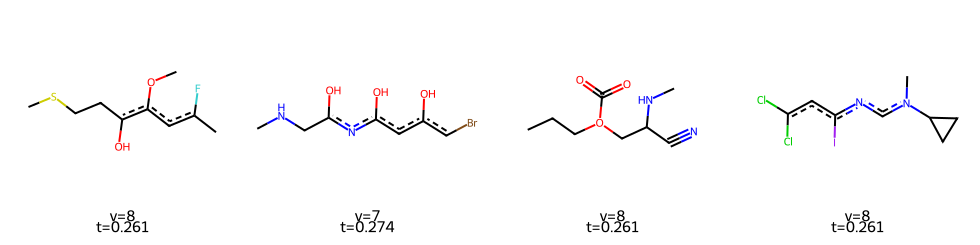

q3: [9, 11] | count=8 | median_violations=10.00 | median_target=0.240


[13:43:11] Explicit valence for atom # 9 Cl, 2, is greater than permitted
[13:43:11] Explicit valence for atom # 1 C, 6, is greater than permitted
[13:43:11] Explicit valence for atom # 11 C, 5, is greater than permitted
[13:43:11] non-ring atom 0 marked aromatic


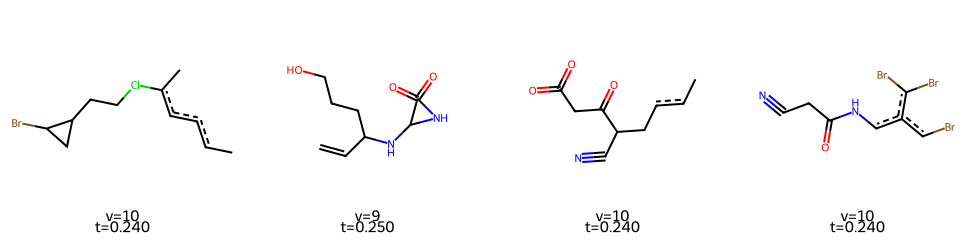

q4: [11, 14] | count=18 | median_violations=12.00 | median_target=0.224


[13:43:11] non-ring atom 0 marked aromatic
[13:43:11] Explicit valence for atom # 0 Br, 2, is greater than permitted
[13:43:11] non-ring atom 4 marked aromatic
[13:43:11] Explicit valence for atom # 4 C, 5, is greater than permitted


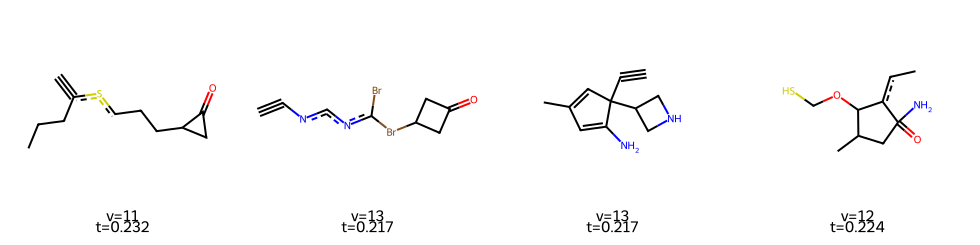

q5: [14, 17] | count=16 | median_violations=15.00 | median_target=0.205


[13:43:11] Can't kekulize mol.  Unkekulized atoms: 0 1 6 10 12


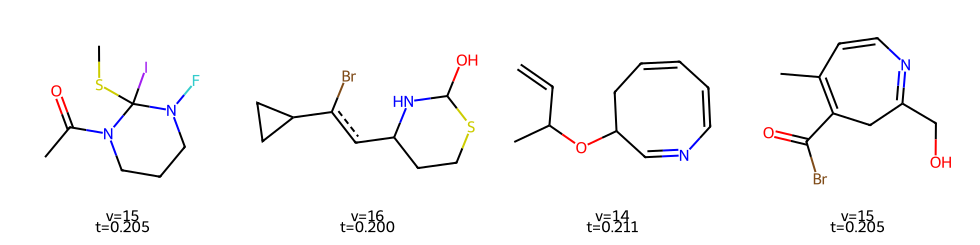

q6: [17, 23] | count=12 | median_violations=20.00 | median_target=0.183


[13:43:11] Explicit valence for atom # 12 C, 5, is greater than permitted
[13:43:11] Explicit valence for atom # 4 Cl, 2, is greater than permitted
[13:43:11] Can't kekulize mol.  Unkekulized atoms: 5 11 12


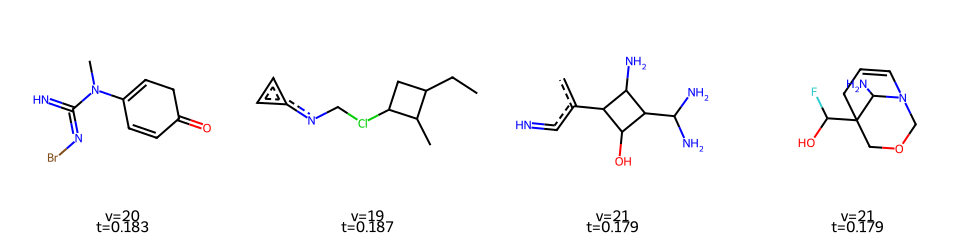

q7: [23, 36] | count=15 | median_violations=28.00 | median_target=0.159


[13:43:11] Can't kekulize mol.  Unkekulized atoms: 9
[13:43:11] non-ring atom 11 marked aromatic
[13:43:11] Can't kekulize mol.  Unkekulized atoms: 1 4 5 6 8 10 12


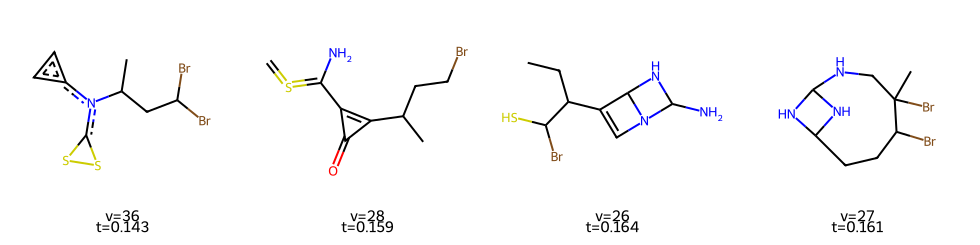

q8: [36, 70] | count=14 | median_violations=44.50 | median_target=0.130


[13:43:11] non-ring atom 1 marked aromatic
[13:43:11] Can't kekulize mol.  Unkekulized atoms: 1 6 7
[13:43:11] Can't kekulize mol.  Unkekulized atoms: 7 10 12


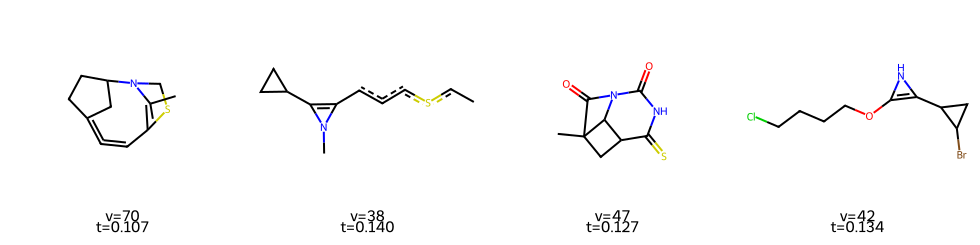

Cycle 6 | unguided=32 guided=96 | collected=128 | feasible_rate=7.0% | mean_violations=15.47 | train_ran=True
feasible | count=9 | median_violations=0.00 | median_target=1.000


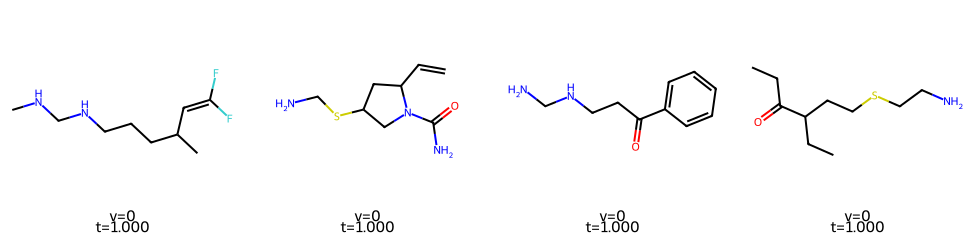

q1: [3, 6] | count=15 | median_violations=4.00 | median_target=0.333


[13:43:11] non-ring atom 6 marked aromatic
[13:43:11] Explicit valence for atom # 5 O, 3, is greater than permitted


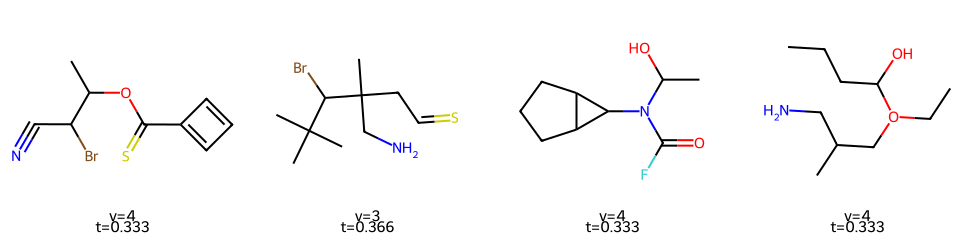

q2: [6, 7] | count=8 | median_violations=6.00 | median_target=0.290


[13:43:11] non-ring atom 0 marked aromatic
[13:43:11] non-ring atom 1 marked aromatic
[13:43:11] non-ring atom 0 marked aromatic


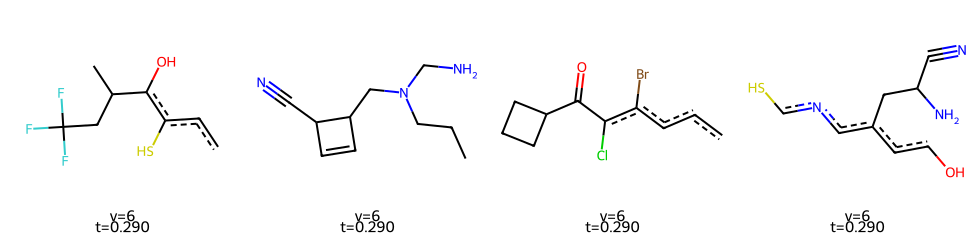

q3: [7, 10] | count=19 | median_violations=8.00 | median_target=0.261


[13:43:11] non-ring atom 1 marked aromatic
[13:43:11] Can't kekulize mol.  Unkekulized atoms: 5
[13:43:11] non-ring atom 2 marked aromatic


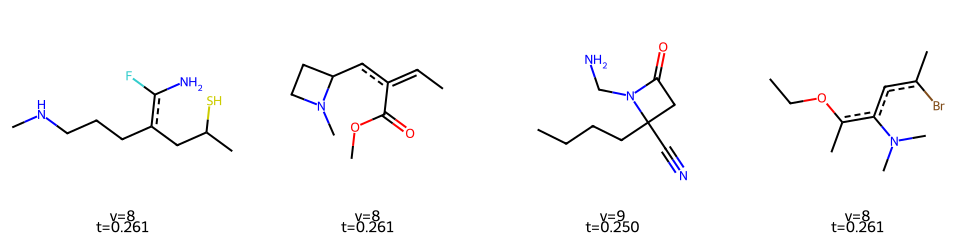

q4: [10, 13] | count=13 | median_violations=11.00 | median_target=0.232


[13:43:11] Explicit valence for atom # 1 O, 3, is greater than permitted
[13:43:11] non-ring atom 0 marked aromatic
[13:43:11] non-ring atom 0 marked aromatic
[13:43:11] Explicit valence for atom # 7 C, 5, is greater than permitted


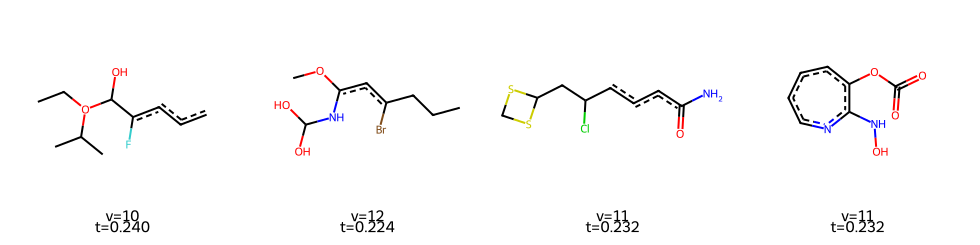

q5: [13, 17] | count=18 | median_violations=14.00 | median_target=0.211


[13:43:11] non-ring atom 2 marked aromatic
[13:43:11] non-ring atom 0 marked aromatic
[13:43:11] Explicit valence for atom # 11 C, 5, is greater than permitted


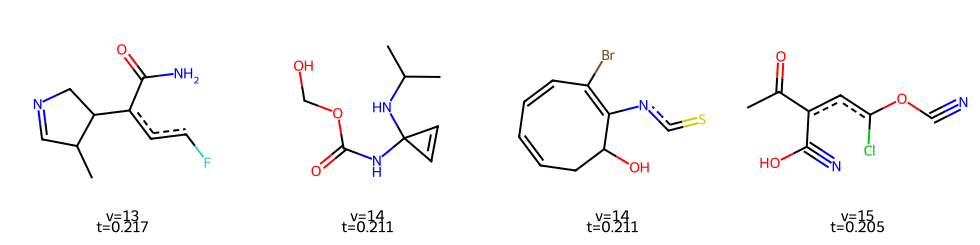

q6: [17, 21] | count=13 | median_violations=19.00 | median_target=0.187


[13:43:11] Can't kekulize mol.  Unkekulized atoms: 8 10 11
[13:43:11] Explicit valence for atom # 4 C, 5, is greater than permitted
[13:43:11] Can't kekulize mol.  Unkekulized atoms: 1
[13:43:11] non-ring atom 1 marked aromatic


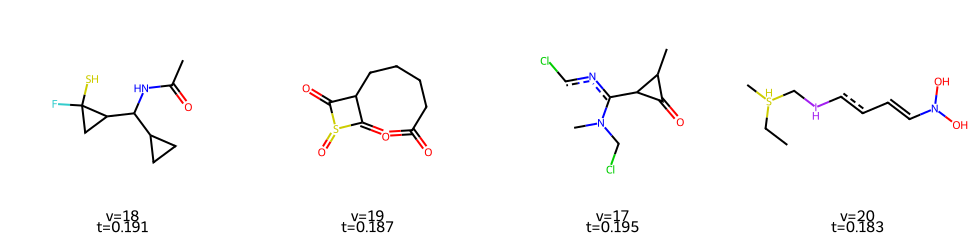

q7: [21, 33] | count=18 | median_violations=22.00 | median_target=0.176


[13:43:11] Explicit valence for atom # 12 C, 5, is greater than permitted
[13:43:11] Can't kekulize mol.  Unkekulized atoms: 4
[13:43:11] Explicit valence for atom # 0 S, 8, is greater than permitted
[13:43:11] Explicit valence for atom # 11 C, 5, is greater than permitted


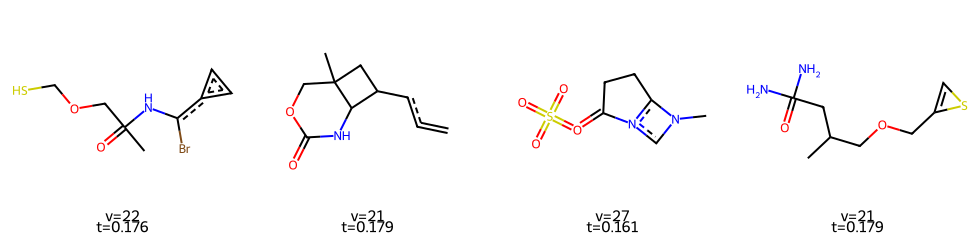

q8: [33, 60] | count=15 | median_violations=43.00 | median_target=0.132


[13:43:11] Can't kekulize mol.  Unkekulized atoms: 3 4 8
[13:43:11] Can't kekulize mol.  Unkekulized atoms: 0 3 6 9 12
[13:43:11] Can't kekulize mol.  Unkekulized atoms: 3 4 8 9 10


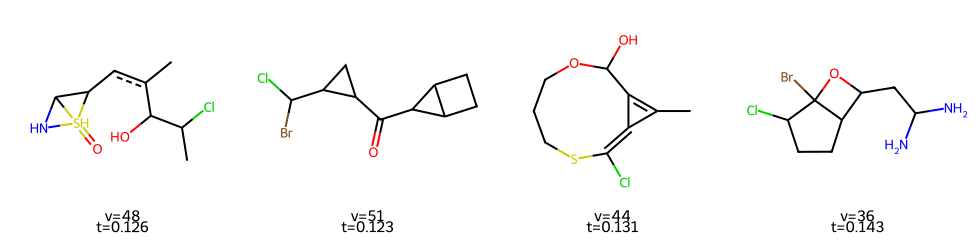

Cycle 7 | unguided=32 guided=96 | collected=128 | feasible_rate=4.7% | mean_violations=15.87 | train_ran=True
feasible | count=6 | median_violations=0.00 | median_target=1.000


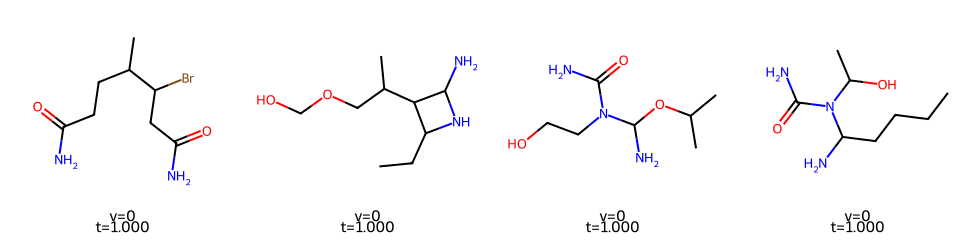

q1: [3, 6] | count=12 | median_violations=4.00 | median_target=0.333


[13:43:11] Explicit valence for atom # 7 C, 5, is greater than permitted
[13:43:11] Explicit valence for atom # 10 C, 5, is greater than permitted
[13:43:11] Can't kekulize mol.  Unkekulized atoms: 3 10 11


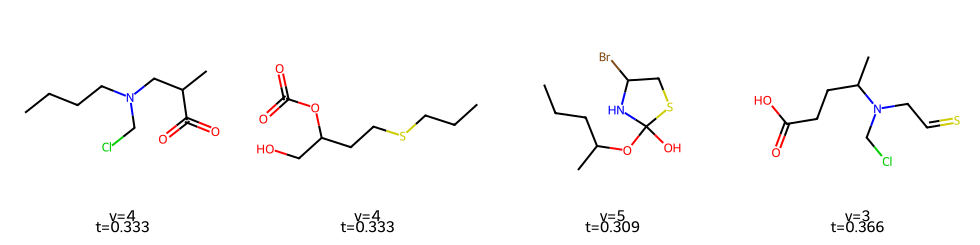

q2: [6, 7] | count=8 | median_violations=6.00 | median_target=0.290


[13:43:11] non-ring atom 0 marked aromatic
[13:43:11] non-ring atom 0 marked aromatic
[13:43:11] non-ring atom 3 marked aromatic
[13:43:11] non-ring atom 5 marked aromatic


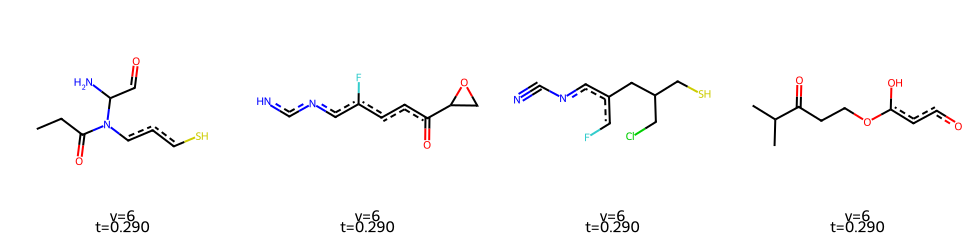

q3: [7, 9] | count=25 | median_violations=7.00 | median_target=0.274


[13:43:11] non-ring atom 1 marked aromatic
[13:43:11] non-ring atom 1 marked aromatic
[13:43:11] Can't kekulize mol.  Unkekulized atoms: 10
[13:43:11] non-ring atom 1 marked aromatic


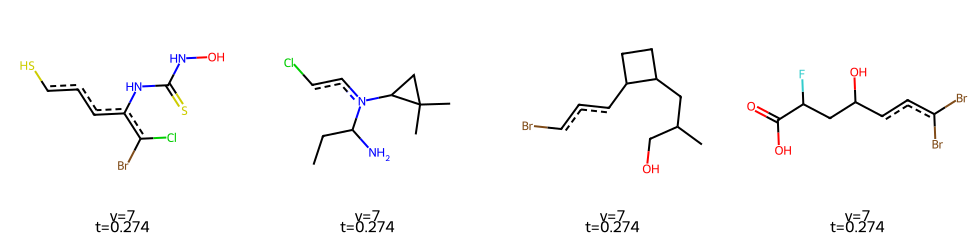

q4: [9, 12] | count=16 | median_violations=10.00 | median_target=0.240


[13:43:11] Explicit valence for atom # 3 C, 5, is greater than permitted
[13:43:11] non-ring atom 3 marked aromatic
[13:43:11] Can't kekulize mol.  Unkekulized atoms: 3 8 9 10 12


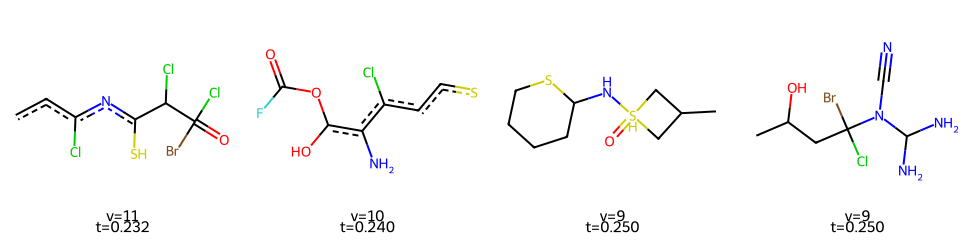

q5: [12, 16] | count=12 | median_violations=13.00 | median_target=0.217


[13:43:11] Can't kekulize mol.  Unkekulized atoms: 1 7 8
[13:43:11] Explicit valence for atom # 7 C, 6, is greater than permitted
[13:43:11] Can't kekulize mol.  Unkekulized atoms: 0 1 10 12
[13:43:11] Explicit valence for atom # 9 C, 5, is greater than permitted


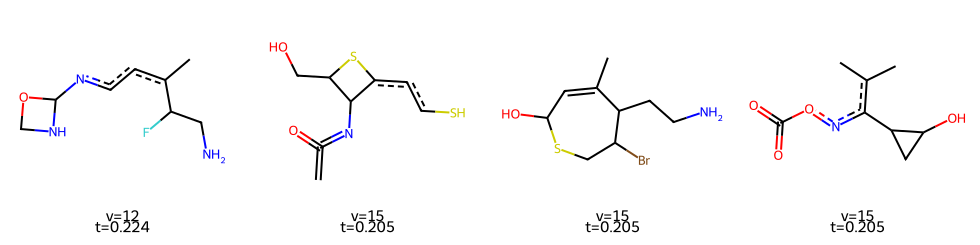

q6: [16, 21] | count=17 | median_violations=18.00 | median_target=0.191


[13:43:11] Can't kekulize mol.  Unkekulized atoms: 7 8 11
[13:43:11] Explicit valence for atom # 1 C, 5, is greater than permitted
[13:43:11] Explicit valence for atom # 8 C, 5, is greater than permitted
[13:43:11] Explicit valence for atom # 7 C, 5, is greater than permitted


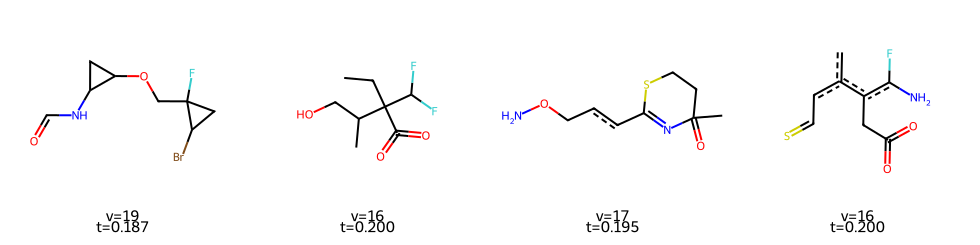

q7: [21, 30] | count=16 | median_violations=24.00 | median_target=0.170


[13:43:11] Explicit valence for atom # 4 C, 5, is greater than permitted
[13:43:11] Explicit valence for atom # 12 C, 5, is greater than permitted


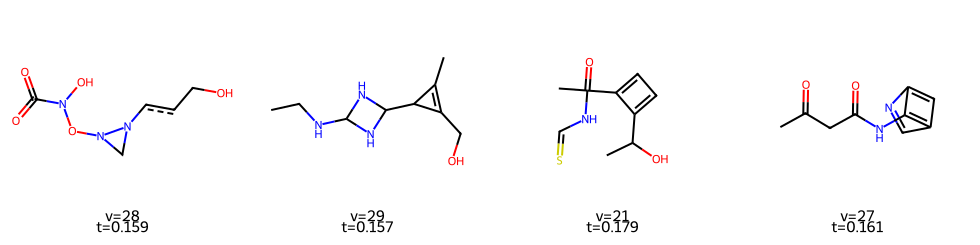

q8: [30, 61] | count=16 | median_violations=47.50 | median_target=0.127


[13:43:11] Explicit valence for atom # 11 C, 6, is greater than permitted
[13:43:11] Explicit valence for atom # 1 O, 4, is greater than permitted
[13:43:11] Explicit valence for atom # 5 N, 5, is greater than permitted
[13:43:11] Can't kekulize mol.  Unkekulized atoms: 1 3 8


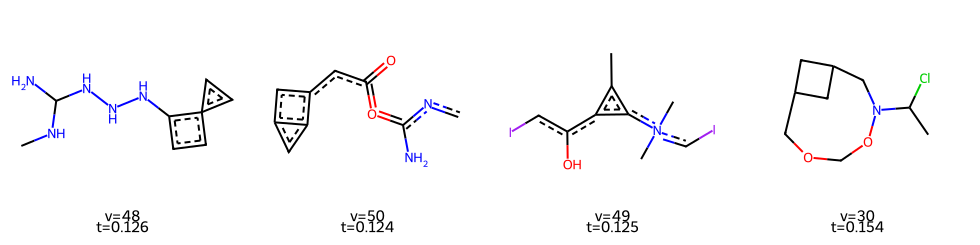

Cycle 8 | unguided=32 guided=96 | collected=128 | feasible_rate=7.0% | mean_violations=14.64 | train_ran=True
feasible | count=9 | median_violations=0.00 | median_target=1.000


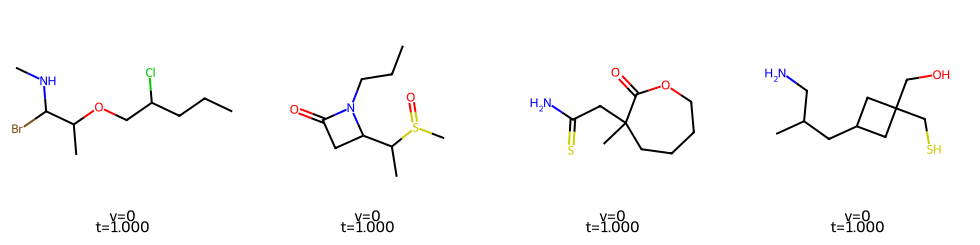

q1: [3, 6] | count=13 | median_violations=4.00 | median_target=0.333


[13:43:11] non-ring atom 7 marked aromatic
[13:43:11] Explicit valence for atom # 2 O, 3, is greater than permitted


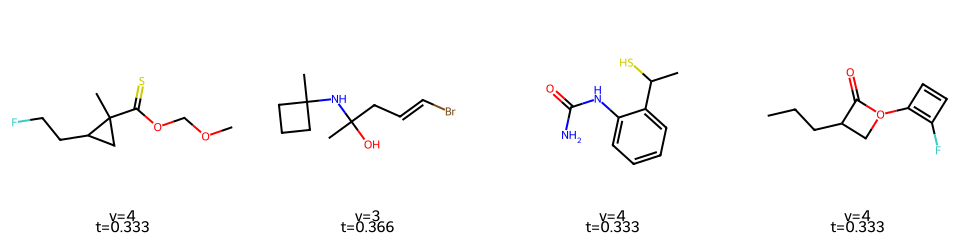

q2: [6, 7] | count=8 | median_violations=6.00 | median_target=0.290


[13:43:11] non-ring atom 0 marked aromatic
[13:43:11] non-ring atom 2 marked aromatic
[13:43:11] non-ring atom 3 marked aromatic
[13:43:11] non-ring atom 0 marked aromatic


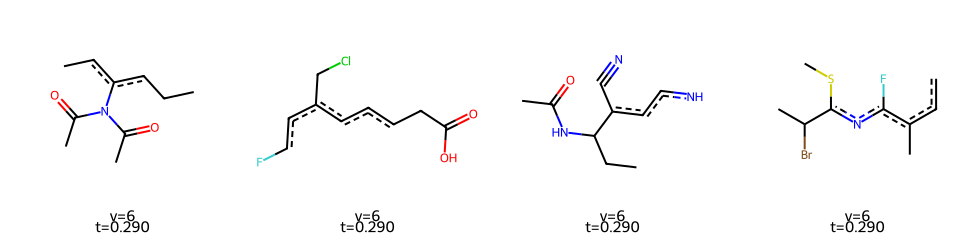

q3: [7, 10] | count=23 | median_violations=7.00 | median_target=0.274


[13:43:11] Explicit valence for atom # 6 C, 5, is greater than permitted
[13:43:11] non-ring atom 3 marked aromatic
[13:43:11] Explicit valence for atom # 0 C, 5, is greater than permitted
[13:43:11] non-ring atom 8 marked aromatic


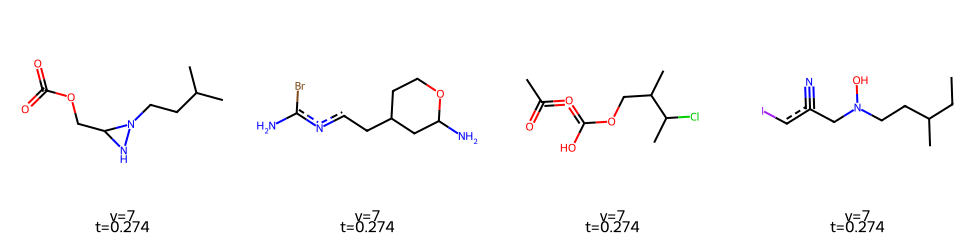

q4: [10, 13] | count=13 | median_violations=11.00 | median_target=0.232


[13:43:11] non-ring atom 2 marked aromatic
[13:43:11] non-ring atom 1 marked aromatic
[13:43:11] Can't kekulize mol.  Unkekulized atoms: 3


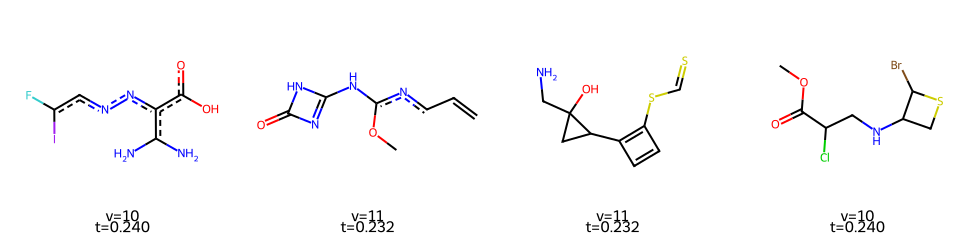

q5: [13, 15] | count=16 | median_violations=14.00 | median_target=0.211


[13:43:11] Can't kekulize mol.  Unkekulized atoms: 0 5 8
[13:43:11] non-ring atom 0 marked aromatic
[13:43:11] Can't kekulize mol.  Unkekulized atoms: 2 5 9


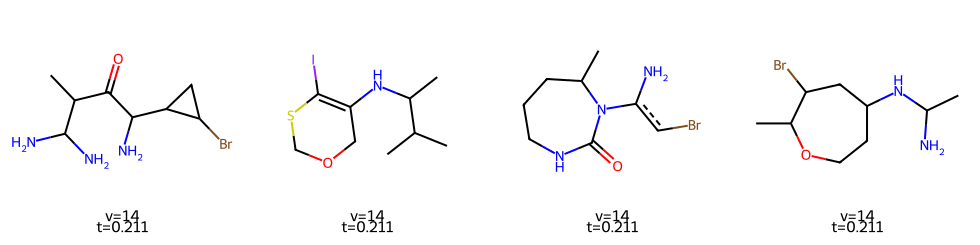

q6: [15, 19] | count=14 | median_violations=16.50 | median_target=0.198


[13:43:11] Explicit valence for atom # 1 C, 5, is greater than permitted
[13:43:11] Can't kekulize mol.  Unkekulized atoms: 0 4 10
[13:43:11] Explicit valence for atom # 12 C, 6, is greater than permitted


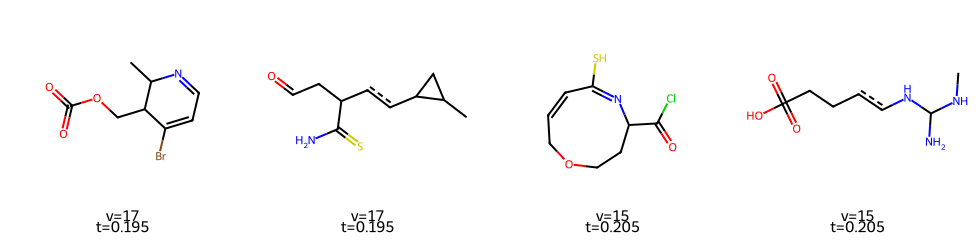

q7: [19, 26] | count=16 | median_violations=21.00 | median_target=0.179


[13:43:11] Can't kekulize mol.  Unkekulized atoms: 5 7 8
[13:43:11] Can't kekulize mol.  Unkekulized atoms: 0 2 3 8 11
[13:43:11] Can't kekulize mol.  Unkekulized atoms: 6 11 12
[13:43:11] Can't kekulize mol.  Unkekulized atoms: 3 6 9


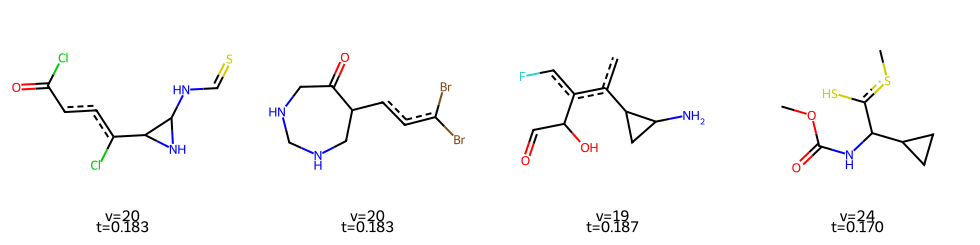

q8: [26, 99] | count=16 | median_violations=37.50 | median_target=0.140


[13:43:11] Can't kekulize mol.  Unkekulized atoms: 0 6 12
[13:43:11] non-ring atom 9 marked aromatic
[13:43:11] Can't kekulize mol.  Unkekulized atoms: 6 7 10
[13:43:11] Explicit valence for atom # 8 C, 5, is greater than permitted


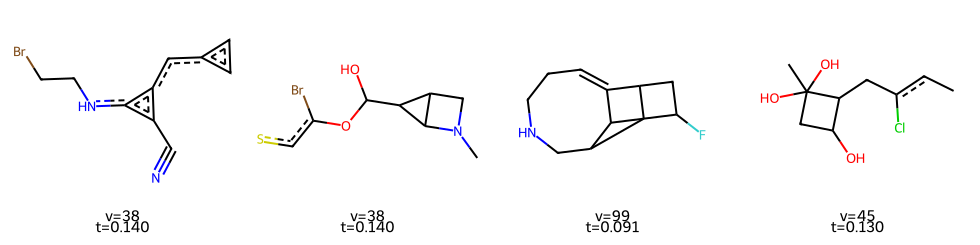

In [10]:
# Plot a random stratified sample from each non-empty violation bucket for every cycle.

for cycle_row, cycle_batch in zip(cycle_history, cycle_batches):
    plot_cycle_bucket_samples(
        graph_generator,
        cycle_batch,
        cycle_row,
        per_bucket=PLOT_MOLECULES_PER_BUCKET,
        positive_bucket_count=POSITIVE_VIOLATION_BUCKETS,
        random_state=PLOT_RANDOM_STATE + int(cycle_row['cycle']),
    )


Paired benchmark summary


,label,count,feasible_count,feasible_rate,feasible_rate_ci_low,feasible_rate_ci_high,mean_violations,median_violations,mean_target,median_target
0,unguided,200,22,0.11,0.073772,0.160927,14.335,12.0,0.309515,0.224009
1,regression_guided,200,20,0.10,0.065670,0.149406,15.305,10.0,0.303524,0.240253


Paired delta summary


,count,guided_only_feasible,unguided_only_feasible,both_feasible,neither_feasible,mean_feasible_rate_delta,feasible_rate_delta_ci_low,feasible_rate_delta_ci_high,mean_violation_delta,violation_delta_ci_low,violation_delta_ci_high,mean_target_delta,target_delta_ci_low,target_delta_ci_high
0,200,15,17,5,163,-0.01,-0.065,0.045,0.97,-1.440375,3.361625,-0.005991,-0.051632,0.037274


Per-sample paired outcomes (head)


,conditioning_index,unguided_feasible,guided_feasible,unguided_violations,guided_violations,violation_delta,unguided_target,guided_target,target_delta
0,0,False,False,15,44,29.0,0.205213,0.131006,-0.074207
1,1,False,False,32,43,11.0,0.150221,0.132320,-0.017901
2,2,True,False,0,53,53.0,1.000000,0.120771,-0.879229
3,3,False,False,25,75,50.0,0.166667,0.103517,-0.063150
4,4,False,True,18,0,-18.0,0.190744,1.000000,0.809256
5,5,False,False,29,20,-9.0,0.156613,0.182744,0.026131
6,6,False,False,16,44,28.0,0.200000,0.131006,-0.068994
7,7,False,False,15,18,3.0,0.205213,0.190744,-0.014470
8,8,False,False,42,10,-32.0,0.133677,0.240253,0.106576
9,9,False,False,12,66,54.0,0.224009,0.109601,-0.114409


Unguided interpolation samples (paired benchmark subset)


[13:46:24] Can't kekulize mol.  Unkekulized atoms: 11
[13:46:24] Can't kekulize mol.  Unkekulized atoms: 1 5 6 8 9 11 12
[13:46:24] Can't kekulize mol.  Unkekulized atoms: 1 4 7
[13:46:24] Can't kekulize mol.  Unkekulized atoms: 2 6 8
[13:46:24] Can't kekulize mol.  Unkekulized atoms: 3 4 5 9 12
[13:46:24] Explicit valence for atom # 9 C, 5, is greater than permitted
[13:46:24] Can't kekulize mol.  Unkekulized atoms: 1 2 3 5 6
[13:46:24] Can't kekulize mol.  Unkekulized atoms: 0 2 3
[13:46:24] Explicit valence for atom # 12 O, 4, is greater than permitted
[13:46:24] non-ring atom 1 marked aromatic
[13:46:24] non-ring atom 3 marked aromatic
[13:46:24] non-ring atom 1 marked aromatic
[13:46:24] Can't kekulize mol.  Unkekulized atoms: 0 1 6 9 11
[13:46:24] non-ring atom 1 marked aromatic
[13:46:24] non-ring atom 1 marked aromatic
[13:46:24] Can't kekulize mol.  Unkekulized atoms: 5 7 10 12
[13:46:24] Explicit valence for atom # 3 O, 4, is greater than permitted
[13:46:24] non-ring atom 2 

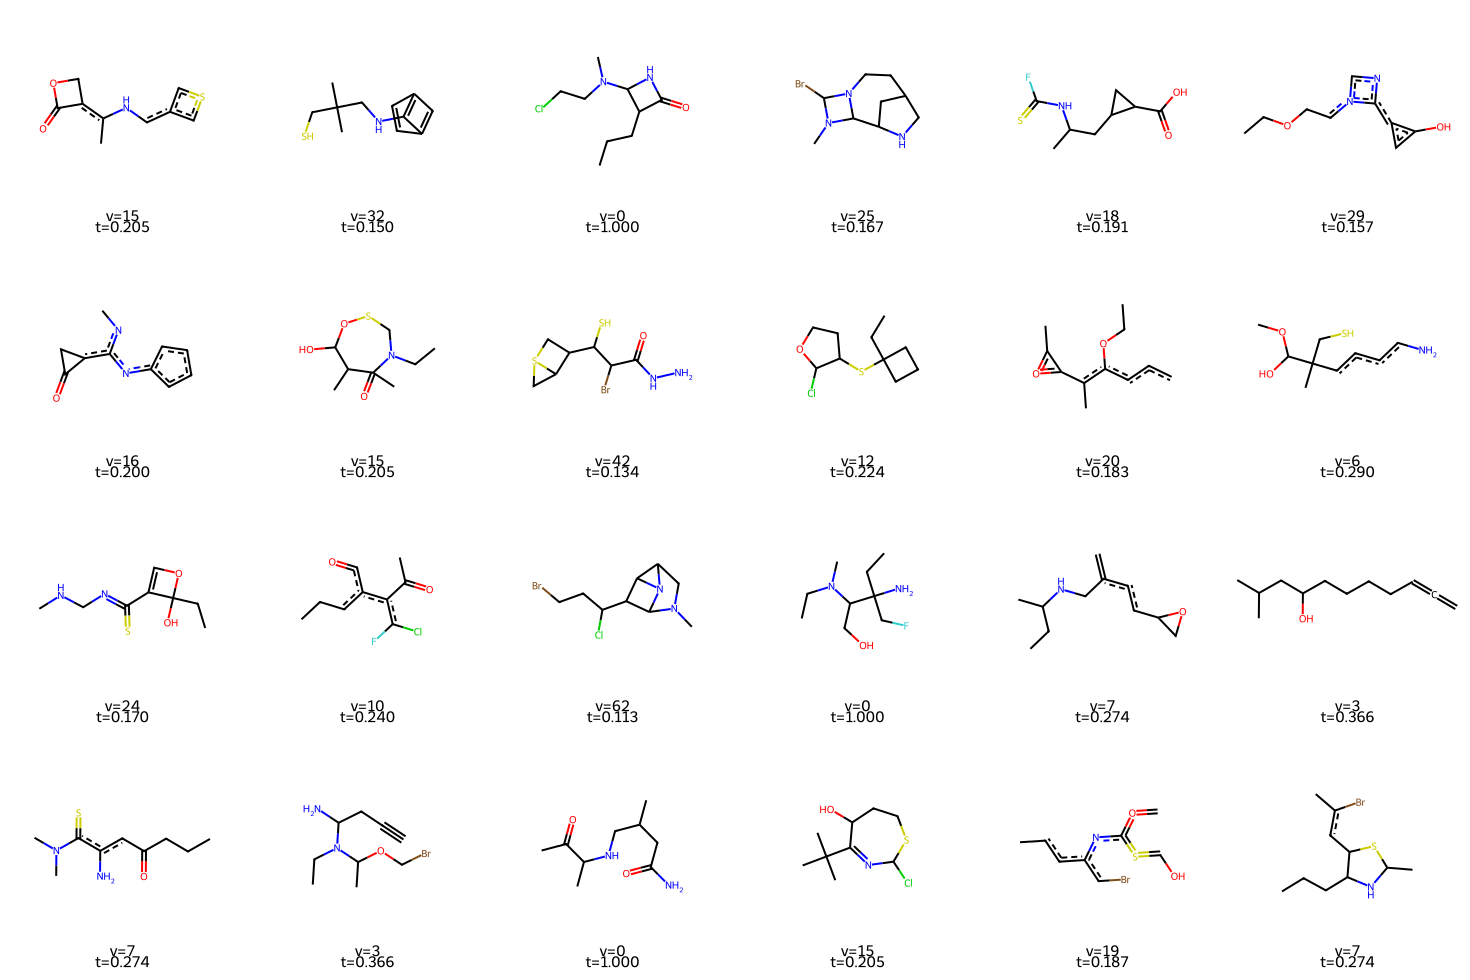

Regression-guided interpolation samples (paired benchmark subset)


[13:46:24] non-ring atom 3 marked aromatic
[13:46:24] Can't kekulize mol.  Unkekulized atoms: 5 6 8
[13:46:24] non-ring atom 1 marked aromatic
[13:46:24] Can't kekulize mol.  Unkekulized atoms: 3 5 6 7 10 11
[13:46:24] Explicit valence for atom # 9 Cl, 2, is greater than permitted
[13:46:24] Can't kekulize mol.  Unkekulized atoms: 1 11 12
[13:46:24] Explicit valence for atom # 12 C, 5, is greater than permitted
[13:46:24] non-ring atom 6 marked aromatic
[13:46:24] Can't kekulize mol.  Unkekulized atoms: 7
[13:46:24] non-ring atom 1 marked aromatic
[13:46:24] Can't kekulize mol.  Unkekulized atoms: 3
[13:46:24] Can't kekulize mol.  Unkekulized atoms: 10
[13:46:24] non-ring atom 5 marked aromatic
[13:46:24] Can't kekulize mol.  Unkekulized atoms: 2 3 11
[13:46:24] Explicit valence for atom # 2 C, 5, is greater than permitted
[13:46:24] non-ring atom 0 marked aromatic
[13:46:24] Explicit valence for atom # 1 C, 6, is greater than permitted
[13:46:24] non-ring atom 0 marked aromatic


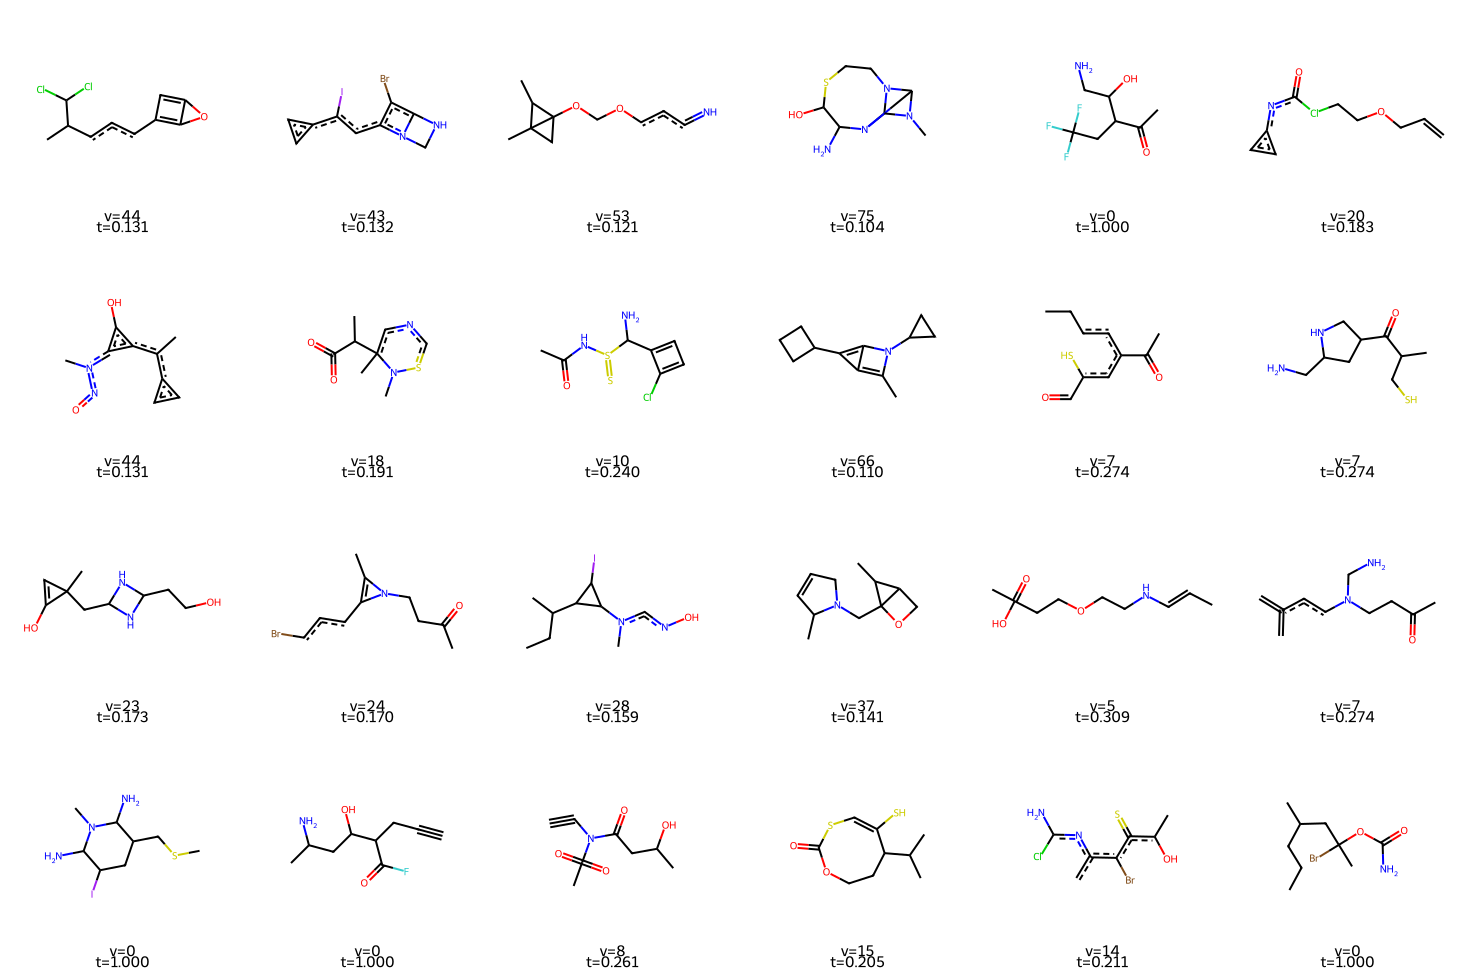

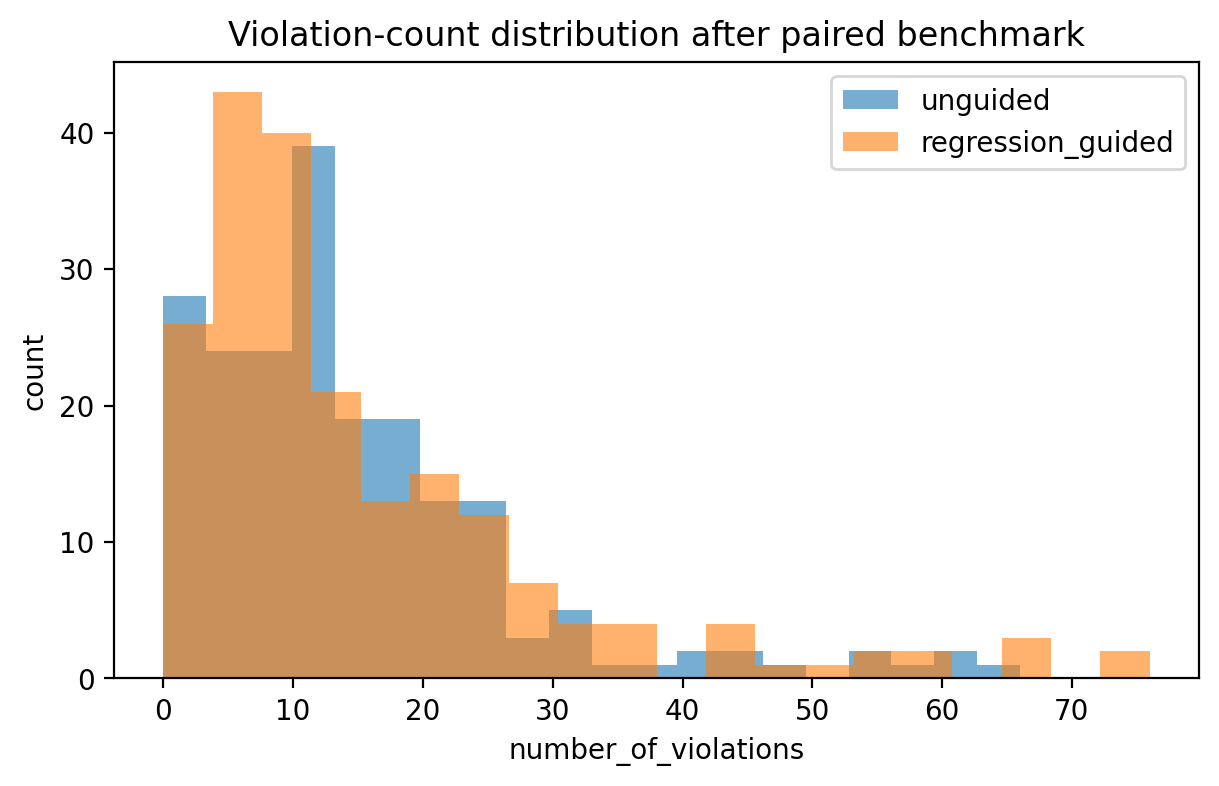

In [11]:
# Run a paired unguided-vs-guided benchmark on the same sampled conditioning,
# then inspect matched sample grids from each mode.

COMPARISON_SAMPLES = 200
DISPLAY_COMPARISON_SAMPLES = 24

guidance_ready = bool(
    getattr(graph_generator.conditional_node_generator_model, 'guidance_predictor_', None) is not None
    and getattr(graph_generator.conditional_node_generator_model, 'guidance_predictor_mode_', None) == 'regression'
)

if not guidance_ready:
    print('Regression guidance predictor is not available; skipping paired benchmark.')
else:
    benchmark_results = benchmark_regression_guidance(
        graph_generator,
        n_samples=COMPARISON_SAMPLES,
        interpolate_between_n_samples=INTERPOLATE_BETWEEN_N_SAMPLES,
        desired_target=GUIDED_TARGET,
        predictor_scale=GUIDANCE_PREDICTOR_SCALE,
        random_state=PLOT_RANDOM_STATE,
    )
    benchmark_summary_df = benchmark_results['summary']
    benchmark_paired_df = benchmark_results['paired_summary']
    benchmark_per_sample_df = benchmark_results['per_sample']
    unguided_batch = benchmark_results['unguided_batch']
    guided_batch = benchmark_results['guided_batch']

    print('Paired benchmark summary')
    display(benchmark_summary_df)
    print('Paired delta summary')
    display(benchmark_paired_df)
    print('Per-sample paired outcomes (head)')
    display(benchmark_per_sample_df.head(12))

    show_molecules(
        unguided_batch.decoded_graphs,
        n=DISPLAY_COMPARISON_SAMPLES,
        title='Unguided interpolation samples (paired benchmark subset)',
        legends=[f"v={int(v)}\nt={float(t):.3f}" for v, t in zip(unguided_batch.violation_counts, unguided_batch.guidance_targets)],
        n_graphs_per_line=6,
    )
    show_molecules(
        guided_batch.decoded_graphs,
        n=DISPLAY_COMPARISON_SAMPLES,
        title='Regression-guided interpolation samples (paired benchmark subset)',
        legends=[f"v={int(v)}\nt={float(t):.3f}" for v, t in zip(guided_batch.violation_counts, guided_batch.guidance_targets)],
        n_graphs_per_line=6,
    )

    plt.figure(figsize=(7, 4))
    plt.hist(unguided_batch.violation_counts, bins=20, alpha=0.6, label='unguided')
    plt.hist(guided_batch.violation_counts, bins=20, alpha=0.6, label='regression_guided')
    plt.xlabel('number_of_violations')
    plt.ylabel('count')
    plt.title('Violation-count distribution after paired benchmark')
    plt.legend()
    plt.show()
